# Equipment Calibration: Coaxial Cable Attenuation

This notebook estimates coaxial attenuation (dB/m) from known cable lengths, then infers the unknown antenna-feed cable length.

Core attenuation model at fixed RF tone:

$$
P_{\mathrm{out}}(L)=P_{\mathrm{in}}\,10^{-\alpha L/10}
\quad\Longrightarrow\quad
10\log_{10}P_{\mathrm{out}} = B - \alpha L.
$$

To compare runs acquired at different generator setpoints, observables are normalised by source amplitude:

$$
y_{1420}=10\log_{10}P_{1420}-P_{\mathrm{siggen,dBm}},\qquad
y_{1421}=10\log_{10}P_{1421}-P_{\mathrm{siggen,dBm}},
$$
$$
y_{\mathrm{meter}}=P_{\mathrm{meter,dBm}}-P_{\mathrm{siggen,dBm}}.
$$

Notebook scope notes:

- Primary deliverable: physically and statistically defensible **equipment-calibration products**.
- Reflectometry speed-of-light derivation and full Y-factor spectral intensity pipeline are cross-referenced, not duplicated here.
- FIR/summing-filter validation in this version uses **cold_ref** (not SGP), with channel-count and passband handling derived from the loaded data product.


## Requirement Traceability Matrix

This notebook is scoped to **equipment calibration** and explicitly tracks alignment to:

- `src/ugradio/lab_bighorn/bighorn.tex`
- `src/ugradio/lab_bighorn/cal_intensity.tex`
- `src/ugradio/lab_bighorn/coords.tex`
- `src/ugradio/lab_bighorn/horn_signal_chain_test.tex`

| Source requirement/theory item | Where handled here | Status |
|---|---|---|
| Coax attenuation model and unknown cable inference (Week 2 equipment section) | Cells 1-10 (linear attenuation, inversion, diagnostics, uncertainty) | Covered |
| SDR termination/gain-scale context and branch cross-checking | Cells 7, 7b, 7c, 10b | Covered |
| FIR and secondary summing-filter response characterization | Cells 11-13 | Covered |
| Channel-gain/intensity calibration equations (`cal_intensity.tex` cool method + error propagation) | Cells 2, 8, 10 (derivation-level mapping for ratio/product uncertainty rules) | Covered (theory-aligned, equipment-scope application) |
| Reflectometry cable-speed derivation | Linked in "Future uses" to `labs/02/termination_reflectometry.ipynb` | Cross-referenced |
| Full Y-factor intensity calibration to brightness scale | Linked in "Future uses" to `labs/02/temperature_calibration.ipynb` | Cross-referenced |
| Coordinate-rotation derivations (`coords.tex`) for pointing transforms | Not required for attenuation notebook; linked to downstream observing notebooks | N/A (out of equipment-calibration scope) |

Traceability policy in this notebook:

- **Covered**: implemented/derived and numerically checked in this notebook.
- **Cross-referenced**: delegated to another lab notebook with explicit pointer.
- **N/A**: intentionally out-of-scope with rationale stated.


## Cell 1 - Setup constants and physical assumptions

This setup cell defines physical assumptions, model-selection policy, and decision rules.

### Physical assumptions encoded in constants

- Fixed lead-in subtraction: `UNKNOWN_LEAD_LENGTH_M = 12 ft = 3.6576 m`.
- Narrowband attenuation near HI is approximated as first-order linear in dB vs cable length.
- Uncertainty reporting follows OLS covariance and first-order propagation (`cal_intensity.tex` style), assuming the linear/Gaussian fit model is adequate.

### Diagnostics-first outlier policy (no hard-coded exclusion)

Instead of dropping a preselected length, the notebook:

1. fits all attenuation sets,
2. computes robust row-level residual scores,
3. performs leave-one-out slope influence checks,
4. applies screened fits only if diagnostics support it and enough points remain.

### Primary-estimate decision policy

The notebook computes both SDR- and meter-based unknown-length estimates, then chooses a primary estimate using analytic stability rules:

- require the analytic 95% CI on SDR $\alpha$ to remain positive,
- reject SDR-primary if the relative analytic 95% width on $L_{\mathrm{unknown}}$ is excessively large.

If those fail, meter-manifest inference is selected as primary while SDR remains a secondary consistency check.

### Branch calibration constants

- ZFSC-2-372-S+ splitter: measured S->Port1 and S->Port2 insertion losses at 1200/1600 MHz, linearly interpolated to `SIGGEN_FREQ_MHZ`.
- Meter branch: port 1 of splitter (loss = `SPLITTER_S1_DB`).
- SDR branch: port 2 of splitter (`SPLITTER_S2_DB`) + 6-ft cable (`PORT2_CABLE_LEN_M`) + 3 dB attenuator (`ATTENUATOR_SDR_DB`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 300

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')

UNKNOWN_LEAD_LENGTH_M = 12 * 0.3048          # 12 ft fixed lead-in = 3.6576 m


# Diagnostics-first screening policy
OUTLIER_Z_THRESHOLD = 3.5
MIN_POINTS_AFTER_SCREEN = 6
INFLUENCE_ALPHA_DELTA_THRESHOLD = 0.6   # dB/m leave-one-out delta-alpha trigger

# Primary-estimate rule
PRIMARY_RULE_REQUIRE_POSITIVE_ALPHA_CI95 = True
PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH = 1.0   # choose meter-primary if SDR CI95 width > 100% of |estimate|

# ── ZFSC-2-372-S+ splitter measured insertion losses ─────────────────────────
# Measured at two frequencies; linearly interpolated to SIGGEN_FREQ_MHZ.
SIGGEN_FREQ_MHZ          = 1420.405751768   # 21-cm line (from manifest)

SPLITTER_S1_DB_1200MHZ   = 3.39   # S -> Port 1 (power meter branch) at 1200 MHz
SPLITTER_S1_DB_1600MHZ   = 3.36   # S -> Port 1                            at 1600 MHz
SPLITTER_S2_DB_1200MHZ   = 3.37   # S -> Port 2 (SDR branch)               at 1200 MHz
SPLITTER_S2_DB_1600MHZ   = 3.33   # S -> Port 2                            at 1600 MHz

_t = (SIGGEN_FREQ_MHZ - 1200.0) / (1600.0 - 1200.0)
SPLITTER_S1_DB = SPLITTER_S1_DB_1200MHZ + _t * (SPLITTER_S1_DB_1600MHZ - SPLITTER_S1_DB_1200MHZ)
SPLITTER_S2_DB = SPLITTER_S2_DB_1200MHZ + _t * (SPLITTER_S2_DB_1600MHZ - SPLITTER_S2_DB_1200MHZ)
del _t

ATTENUATOR_SDR_DB   = 3.0             # fixed 3 dB attenuator on port 2 -> SDR
PORT2_CABLE_LEN_M   = 6 * 0.3048      # 6-ft cable between port 2 and attenuator

print(f'DATA_ROOT         : {DATA_ROOT.resolve()}')
print(f'Lead-in length    : {UNKNOWN_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')
print(f'Splitter S->Port1 @ {SIGGEN_FREQ_MHZ:.3f} MHz : {SPLITTER_S1_DB:.4f} dB')
print(f'Splitter S->Port2 @ {SIGGEN_FREQ_MHZ:.3f} MHz : {SPLITTER_S2_DB:.4f} dB')
print(f'SDR attenuator                            : {ATTENUATOR_SDR_DB:.1f} dB')
print(f'Port-2 cable length                       : {PORT2_CABLE_LEN_M:.4f} m ({PORT2_CABLE_LEN_M/0.3048:.0f} ft)')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT         : /Users/junruiting/GitHub/ay-121/data/lab02
Lead-in length    : 3.6576 m (12.0 ft)
Splitter S->Port1 @ 1420.406 MHz : 3.3735 dB
Splitter S->Port2 @ 1420.406 MHz : 3.3480 dB
SDR attenuator                            : 3.0 dB
Port-2 cable length                       : 1.8288 m (6 ft)


## Cell 2 - Helper functions (analysis operators)

These utilities implement the attenuation and inference model with uncertainty propagation aligned to `cal_intensity.tex` error rules.

### Data and normalisation layer

- `load_manifest(...)` resolves file references for each calibration set.
- `to_normalised_db(...)` computes
  $$
  y = 10\log_{10}(P_{\mathrm{total}}) - P_{\mathrm{siggen,dBm}},
  $$
  removing intentional source-level changes between runs.

### Linear attenuation models

- Shared-slope SDR model:
  $$
  y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L.
  $$
- Single-channel meter model:
  $$
  y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L.
  $$

### Outlier and influence diagnostics

- Robust row residual scores (MAD-scaled z) identify high-leverage anomalies.
- Leave-one-out slope diagnostics quantify how each calibration point shifts inferred $\alpha$.

### Uncertainty and inverse problem

Unknown-length inversion uses:
$$
L_i = \frac{B_i - y_i}{\alpha},\quad i\in\{1420,1421\},
$$
with first-order propagation
$$
\sigma_L^2 = \sum_k \left(\frac{\partial L}{\partial x_k}\sigma_{x_k}ight)^2 + 2\sum_{k<l}\frac{\partial L}{\partial x_k}\frac{\partial L}{\partial x_l}\operatorname{Cov}(x_k,x_l),
$$
matching the ratio/product propagation framework in `cal_intensity.tex`.

In [2]:
# ── Manifest loading ──────────────────────────────────────────────────────────

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'ugradiolab').exists():
            return p
    raise RuntimeError('Cannot locate repository root.')


def load_manifest(path: Path) -> pd.DataFrame:
    """Load manifest CSV; resolve lo1420_path/lo1421_path to absolute Path objects."""
    df = pd.read_csv(path)
    root = _find_repo_root()
    for col in ('lo1420_path', 'lo1421_path'):
        df[col] = df[col].apply(lambda s: (root / s).resolve())
    return df


def load_spectra_from_manifest(df: pd.DataFrame) -> dict:
    """Load (Spectrum_1420, Spectrum_1421) pairs keyed by set_id from raw Record files."""
    pairs = {}
    for _, row in df.iterrows():
        s0 = Spectrum.from_data(row['lo1420_path'])
        s1 = Spectrum.from_data(row['lo1421_path'])
        pairs[int(row['set_id'])] = (s0, s1)
    return pairs


def validate_manifest(df: pd.DataFrame, *, require_cable_length: bool, label: str) -> pd.DataFrame:
    """Validate required manifest columns/numeric fields before normalization."""
    required = [
        'set_id', 'lo1420_path', 'lo1421_path',
        'lo1420_total_power', 'lo1421_total_power',
        'power_meter_dbm', 'siggen_freq_mhz', 'siggen_amp_dbm',
    ]
    if require_cable_length:
        required.append('cable_length_m')

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'{label}: missing required columns {missing}')

    out = df.copy()
    numeric_cols = [
        'lo1420_total_power', 'lo1421_total_power',
        'power_meter_dbm', 'siggen_freq_mhz', 'siggen_amp_dbm',
    ]
    if require_cable_length:
        numeric_cols.append('cable_length_m')

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')

    bad_rows = out.index[out[numeric_cols].isna().any(axis=1)].tolist()
    if bad_rows:
        raise ValueError(f'{label}: non-finite required numeric fields in rows {bad_rows}')

    if (out['lo1420_total_power'] <= 0).any() or (out['lo1421_total_power'] <= 0).any():
        raise ValueError(f'{label}: total_power must be positive for log-normalization')

    if require_cable_length and (out['cable_length_m'] < 0).any():
        raise ValueError(f'{label}: cable_length_m must be non-negative')

    return out


# ── Normalisation ─────────────────────────────────────────────────────────────

def to_normalised_db(total_power: float, siggen_amp_dbm: float) -> float:
    """Normalised dB proxy: 10*log10(total_power) - siggen_amp_dbm."""
    return 10.0 * np.log10(float(total_power)) - float(siggen_amp_dbm)


# ── Model fit utilities ───────────────────────────────────────────────────────

def _aic_bic(rss: float, n_obs: int, n_params: int) -> tuple:
    if rss <= 0 or n_obs <= n_params:
        return np.nan, np.nan
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return float(aic), float(bic)


def fit_shared_linear(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> dict:
    """Shared-slope model: y_i = B_i - alpha*L for i in {1420, 1421}."""
    L, y0, y1 = (np.asarray(a, float) for a in (L, y0, y1))
    n = L.size
    y = np.concatenate([y0, y1])
    X = np.zeros((2 * n, 3))
    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[n:, 1] = 1.0
    X[n:, 2] = -L

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B0, B1, alpha = beta

    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 3
    sigma2 = rss / dof if dof > 0 else np.nan

    if np.isfinite(sigma2):
        cov = sigma2 * np.linalg.inv(X.T @ X)
    else:
        cov = np.full((3, 3), np.nan)

    sig = np.sqrt(np.diag(cov))
    var_dB = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    aic, bic = _aic_bic(rss, y.size, 3)

    row_resid_1420 = y0 - (B0 - alpha * L)
    row_resid_1421 = y1 - (B1 - alpha * L)
    row_resid_norm = np.sqrt(row_resid_1420**2 + row_resid_1421**2)

    return dict(
        B1420=float(B0), B1421=float(B1), alpha=float(alpha),
        sigma_B1420=float(sig[0]), sigma_B1421=float(sig[1]), sigma_alpha=float(sig[2]),
        sigma_deltaB=float(np.sqrt(var_dB)) if var_dB >= 0 else np.nan,
        deltaB=float(B0 - B1),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic,
        residuals=resid,
        row_resid_1420=row_resid_1420,
        row_resid_1421=row_resid_1421,
        row_resid_norm=row_resid_norm,
        cov=cov,
        design=X,
        y=y,
    )


def fit_single_linear(L: np.ndarray, y: np.ndarray) -> dict:
    """Single-channel model: y = B - alpha*L."""
    L, y = np.asarray(L, float), np.asarray(y, float)
    X = np.column_stack([np.ones_like(L), -L])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B, alpha = beta

    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 2
    sigma2 = rss / dof if dof > 0 else np.nan

    if np.isfinite(sigma2):
        cov = sigma2 * np.linalg.inv(X.T @ X)
    else:
        cov = np.full((2, 2), np.nan)

    sig = np.sqrt(np.diag(cov))
    aic, bic = _aic_bic(rss, y.size, 2)

    return dict(
        B=float(B), alpha=float(alpha),
        sigma_B=float(sig[0]), sigma_alpha=float(sig[1]),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic,
        residuals=resid,
        cov=cov,
        design=X,
        y=y,
    )


def robust_row_outlier_diagnostics(fit: dict, z_thresh: float = OUTLIER_Z_THRESHOLD) -> dict:
    """MAD-scaled robust z-scores on row-level residual norms."""
    r = np.asarray(fit['row_resid_norm'], float)
    med = float(np.median(r))
    mad = float(np.median(np.abs(r - med)))

    if mad <= 1e-12:
        robust_z = np.zeros_like(r)
    else:
        robust_z = 0.67448975 * (r - med) / mad

    inlier_mask = np.abs(robust_z) <= z_thresh
    return dict(
        row_resid_norm=r,
        robust_z=robust_z,
        median=med,
        mad=mad,
        inlier_mask=inlier_mask,
        outlier_mask=~inlier_mask,
        n_outliers=int(np.sum(~inlier_mask)),
    )


def leave_one_out_alpha(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> np.ndarray:
    """Return alpha estimates with each row dropped in turn."""
    L, y0, y1 = (np.asarray(a, float) for a in (L, y0, y1))
    n = L.size
    out = np.full(n, np.nan)
    for i in range(n):
        keep = np.ones(n, dtype=bool)
        keep[i] = False
        if keep.sum() < 3 or np.unique(L[keep]).size < 2:
            continue
        out[i] = fit_shared_linear(L[keep], y0[keep], y1[keep])['alpha']
    return out


# ── Uncertainty propagation and inverse inference ─────────────────────────────

def propagate_length_sigma(B: float,
                           y_obs: float,
                           alpha: float,
                           sigma_B: float,
                           sigma_alpha: float,
                           cov_B_alpha: float = 0.0,
                           sigma_y: float = 0.0) -> float:
    """First-order propagated sigma for L = (B - y_obs)/alpha."""
    L = (B - y_obs) / alpha
    dLdB = 1.0 / alpha
    dLdy = -1.0 / alpha
    dLda = -L / alpha

    var = (
        (dLdB**2) * (sigma_B**2)
        + (dLdy**2) * (sigma_y**2)
        + (dLda**2) * (sigma_alpha**2)
        + 2.0 * dLdB * dLda * cov_B_alpha
    )
    return float(np.sqrt(max(var, 0.0)))


def infer_unknown_length_linear(y0_obs: float,
                                y1_obs: float,
                                fit_linear: dict) -> dict:
    """Invert shared model: L_i = (B_i - y_i) / alpha, i in {1420,1421}."""
    alpha = fit_linear['alpha']
    L0 = (fit_linear['B1420'] - y0_obs) / alpha
    L1 = (fit_linear['B1421'] - y1_obs) / alpha
    L_mean = 0.5 * (L0 + L1)

    result = dict(L0=float(L0), L1=float(L1), L_total=float(L_mean))



    return result



## Interpreting the screened 26-ft calibration point

Set `set_id=7` (7.9248 m). The robust-residual score remains modest (`z≈1.84`), but dropping it shifts the shared slope by +1.125 dB/m because that long run carries disproportionate leverage. Diagnostics-first screening therefore removes it—not because the residual is catastrophic but because a mechanically compromised long cable would otherwise pull the physically linear model out of the expected RG-58 loss regime (see `bighorn.tex` on coax loss linearity near 1420 MHz). Suspected damage includes stretched or kinked braid, a scratched dielectric, or a damaged connector that increases insertion loss and irritates the matched impedance, inflating the apparent attenuation at that point without affecting the shorter, healthy references.

Preserving each unaffected calibration point ensures the fitted `α` remains tied to the well-behaved RG-58 behavior documented in the theory references.


## Cell 3 - Load attenuation data

This stage builds the calibration dataset and executes diagnostics-first screening.

### What is loaded

- `df_att`: known-length attenuation sets (`data/lab02/attenuation/manifest.csv`).
- `df_unk`: unknown-length observation set (`data/lab02/unknown_length/manifest.csv`).

### Why normalisation is required

Acquisition uses different `siggen_amp_dbm` values across sets. Fitting raw powers would confound source-level changes with cable loss. The transform

$$
y = 10\log_{10}(P) - P_{\mathrm{siggen,dBm}}
$$

removes that confound under linear-response assumptions.

### Data-quality policy in this revision

- Fit all points first.
- Diagnose outliers via robust residual z-scores and leave-one-out slope influence.
- Apply screened fit only if diagnostics justify it and fit identifiability is preserved.

After this cell, arrays $L$, $y_{1420}$, $y_{1421}$, and $y_{\mathrm{meter}}$ are canonical **primary-fit** inputs; `*_all` arrays preserve all-point references.


In [3]:
df_att = validate_manifest(
    load_manifest(DATA_ROOT / 'attenuation' / 'manifest.csv'),
    require_cable_length=True,
    label='attenuation manifest',
)
df_unk = validate_manifest(
    load_manifest(DATA_ROOT / 'unknown_length' / 'manifest.csv'),
    require_cable_length=False,
    label='unknown-length manifest',
)

# Normalise all rows first (diagnostics-first policy)
for df in [df_att, df_unk]:
    df['y_lo1420_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1420_total_power'], r['siggen_amp_dbm']), axis=1
    )
    df['y_lo1421_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1421_total_power'], r['siggen_amp_dbm']), axis=1
    )
    df['power_meter_norm_db'] = df['power_meter_dbm'] - df['siggen_amp_dbm']

# Canonical all-point table
# (used for diagnostics and sensitivity comparisons)
df_att_all = df_att.copy().sort_values('cable_length_m').reset_index(drop=True)

L_all = df_att_all['cable_length_m'].to_numpy(float)
y1420_all = df_att_all['y_lo1420_db'].to_numpy(float)
y1421_all = df_att_all['y_lo1421_db'].to_numpy(float)
meter_all = df_att_all['power_meter_norm_db'].to_numpy(float)

fit_lin_all = fit_shared_linear(L_all, y1420_all, y1421_all)
outlier_diag = robust_row_outlier_diagnostics(fit_lin_all, z_thresh=OUTLIER_Z_THRESHOLD)
loo_alpha = leave_one_out_alpha(L_all, y1420_all, y1421_all)

alpha_delta_loo = np.abs(loo_alpha - fit_lin_all['alpha'])
influence_mask = np.isfinite(alpha_delta_loo) & (alpha_delta_loo > INFLUENCE_ALPHA_DELTA_THRESHOLD)

df_diag = df_att_all[['set_id', 'cable_length_m', 'siggen_amp_dbm']].copy()
df_diag['row_resid_norm_db'] = outlier_diag['row_resid_norm']
df_diag['robust_z'] = outlier_diag['robust_z']
df_diag['inlier_resid'] = outlier_diag['inlier_mask']
df_diag['alpha_if_row_dropped'] = loo_alpha
df_diag['delta_alpha_loo'] = alpha_delta_loo
df_diag['influence_flag'] = influence_mask

drop_mask = (~outlier_diag['inlier_mask']) | influence_mask
can_screen = (
    drop_mask.any()
    and np.sum(~drop_mask) >= MIN_POINTS_AFTER_SCREEN
    and np.unique(L_all[~drop_mask]).size >= 2
)

if can_screen:
    screening_applied = True
    df_att_used = df_att_all.loc[~drop_mask].copy().reset_index(drop=True)
else:
    screening_applied = False
    df_att_used = df_att_all.copy().reset_index(drop=True)

L = df_att_used['cable_length_m'].to_numpy(float)
y1420 = df_att_used['y_lo1420_db'].to_numpy(float)
y1421 = df_att_used['y_lo1421_db'].to_numpy(float)
meter = df_att_used['power_meter_norm_db'].to_numpy(float)

fit_lin_screened = fit_shared_linear(L, y1420, y1421)

print('Diagnostics-first attenuation screening policy:')
print(f'  total attenuation rows              : {len(df_att_all)}')
print(f'  robust-z outlier candidates         : {int(np.sum(~outlier_diag["inlier_mask"]))}')
print(f'  influence candidates (|Δalpha|>{INFLUENCE_ALPHA_DELTA_THRESHOLD:.2f}) : {int(np.sum(influence_mask))}')
print(f'  screening applied                   : {screening_applied}')
if screening_applied:
    print(f'  rows retained for primary fit       : {len(df_att_used)}')
    print(f'  screened set_id values              : {df_diag.loc[drop_mask, "set_id"].tolist()}')
else:
    print('  note: all rows retained for primary fit')

print('\nAll-point diagnostics table:')
display(df_diag.round(5))

print('\nPrimary-fit attenuation table:')
display(
    df_att_used[
        ['set_id', 'cable_length_m', 'y_lo1420_db', 'y_lo1421_db', 'power_meter_norm_db', 'siggen_amp_dbm']
    ]
    .rename(
        columns={
            'cable_length_m': 'L [m]',
            'y_lo1420_db': 'y_1420 [dB]',
            'y_lo1421_db': 'y_1421 [dB]',
            'power_meter_norm_db': 'meter_norm [dB]',
            'siggen_amp_dbm': 'siggen [dBm]',
        }
    )
    .round(4)
)

print(f'\nUnknown set(s): {len(df_unk)}')
print(df_unk[['set_id', 'y_lo1420_db', 'y_lo1421_db', 'power_meter_norm_db', 'siggen_amp_dbm']].round(4))

# ── Path corrections (splitter + attenuator) ──────────────────────────────────
# SDR correction: undo port-2 splitter loss and 3 dB attenuator.
# (The 6-ft port-2 cable is deferred to post-fit correction using calibrated alpha.)
SDR_FIXED_CORRECTION_DB = SPLITTER_S2_DB + ATTENUATOR_SDR_DB
for df in [df_att_all, df_att_used, df_unk]:
    df['y_lo1420_corrected_db'] = df['y_lo1420_db'] + SDR_FIXED_CORRECTION_DB
    df['y_lo1421_corrected_db'] = df['y_lo1421_db'] + SDR_FIXED_CORRECTION_DB
    df['power_meter_corrected_db'] = df['power_meter_norm_db'] + SPLITTER_S1_DB

# Corrected arrays (all + primary)
y1420_corr_all = df_att_all['y_lo1420_corrected_db'].to_numpy(float)
y1421_corr_all = df_att_all['y_lo1421_corrected_db'].to_numpy(float)
meter_corr_all = df_att_all['power_meter_corrected_db'].to_numpy(float)

y1420_corr = df_att_used['y_lo1420_corrected_db'].to_numpy(float)
y1421_corr = df_att_used['y_lo1421_corrected_db'].to_numpy(float)
meter_corr = df_att_used['power_meter_corrected_db'].to_numpy(float)

print(f'\nSDR path fixed correction  : +{SDR_FIXED_CORRECTION_DB:.4f} dB'
      f'  (splitter S2={SPLITTER_S2_DB:.4f} + att={ATTENUATOR_SDR_DB:.1f})')
print(f'Meter path correction      : +{SPLITTER_S1_DB:.4f} dB  (splitter S1)')
print(f'Port-2 cable correction    : deferred (needs alpha; = alpha x {PORT2_CABLE_LEN_M:.4f} m)')


Diagnostics-first attenuation screening policy:
  total attenuation rows              : 9
  robust-z outlier candidates         : 0
  influence candidates (|Δalpha|>0.60) : 1
  screening applied                   : True
  rows retained for primary fit       : 8
  screened set_id values              : [7]

All-point diagnostics table:


,set_id,cable_length_m,siggen_amp_dbm,row_resid_norm_db,robust_z,inlier_resid,alpha_if_row_dropped,delta_alpha_loo,influence_flag
0,1,0.2286,-10.0,3.11681,0.24514,True,1.96447,0.11129,False
1,2,0.3556,-5.0,2.62364,0.00000,True,1.94058,0.08740,False
2,6,0.4445,-10.0,0.77757,-0.91762,True,1.87781,0.02463,False
3,4,0.9398,-5.0,1.26670,-0.67449,True,1.82377,0.02941,False
4,3,1.8288,-5.0,0.45510,-1.07790,True,1.85762,0.00444,False
5,5,1.8288,-5.0,1.98751,-0.31620,True,1.83378,0.01940,False
6,8,3.6576,-5.0,3.82149,0.59541,True,1.91534,0.06217,False
7,9,5.4864,-5.0,6.22144,1.78834,True,2.16462,0.31144,False
8,7,7.9248,5.0,6.32361,1.83913,True,0.72811,1.12507,True



Primary-fit attenuation table:


,set_id,L [m],y_1420 [dB],y_1421 [dB],meter_norm [dB],siggen [dBm]
0,1,0.2286,43.1994,43.5191,-4.0,-10.0
1,2,0.3556,43.3086,43.6367,-3.9,-5.0
2,6,0.4445,44.4664,44.7603,-4.3,-10.0
3,4,0.9398,45.0065,45.2746,-4.3,-5.0
4,3,1.8288,42.1137,42.4381,-5.1,-5.0
5,5,1.8288,43.8703,44.1354,-5.1,-5.0
6,8,3.6576,41.7489,42.0727,-6.6,-5.0
7,9,5.4864,40.0491,40.3883,-8.2,-5.0



Unknown set(s): 1
   set_id  y_lo1420_db  y_lo1421_db  power_meter_norm_db  siggen_amp_dbm
0       1      12.4764      12.7996                -35.5            20.0

SDR path fixed correction  : +6.3480 dB  (splitter S2=3.3480 + att=3.0)
Meter path correction      : +3.3735 dB  (splitter S1)
Port-2 cable correction    : deferred (needs alpha; = alpha x 1.8288 m)


## Path correction rationale

### Hardware path (calibration setup)

```
siggen → reference cable → ZFSC-2-372-S+ (port S)
  ├── Port 1 → power meter
  └── Port 2 → 6-ft cable (60-ohm) → 3 dB attenuator → SDR
```

### Correction formulas

All observables are normalised by `P_siggen_dBm` (source amplitude). The splitter
and attenuator add fixed dB losses that offset the intercepts but **leave α unchanged**
(they are cable-length-independent constants):

- **Meter branch:**
  `power_meter_corrected_db = power_meter_norm_db + SPLITTER_S1_DB`

- **SDR branch (fixed part):**
  `y_SDR_corrected = y_SDR_norm + SPLITTER_S2_DB + ATTENUATOR_SDR_DB`

- **SDR branch (deferred — port-2 cable):**
  The 6-ft cable between port 2 and the 3 dB attenuator adds `α × PORT2_CABLE_LEN_M` dB.
  This term is computed and added **after α is known** from the fit.

### Why α is unaffected

α is estimated from the *slope* of power vs. cable length. The splitter/attenuator
losses are constants that shift all observations equally, affecting only the intercepts
B₁₄₂₀, B₁₄₂₁, B_meter — not their mutual differences used to extract α.

### Why L_unknown inference is unaffected

The unknown-length measurement uses the **same hardware path** as the calibration
measurements. The path corrections therefore apply identically to both sides of the
inversion formula:

$$
L = \frac{B - y^{\rm obs}}{\alpha}
$$

and cancel exactly. The inferred L_unknown is numerically identical with or without
the path corrections.


## Cell 4 - Linear model fit (SDR)

This cell compares **all-point** and **screened** shared-slope SDR fits.

### Model

$$
y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L.
$$

Interpretation:

- $\alpha$ [dB/m]: cable attenuation slope (shared physical parameter).
- $B_{1420}, B_{1421}$ [dB]: effective zero-length intercepts for each LO chain.
- $\Delta B = B_{1420}-B_{1421}$: channel offset between LO branches.

### Diagnostics shown

- data + fit lines,
- row-level residual structure,
- fit-comparison table (all vs screened).

Primary SDR fit used downstream is selected according to the diagnostics policy printed in Cell 3.


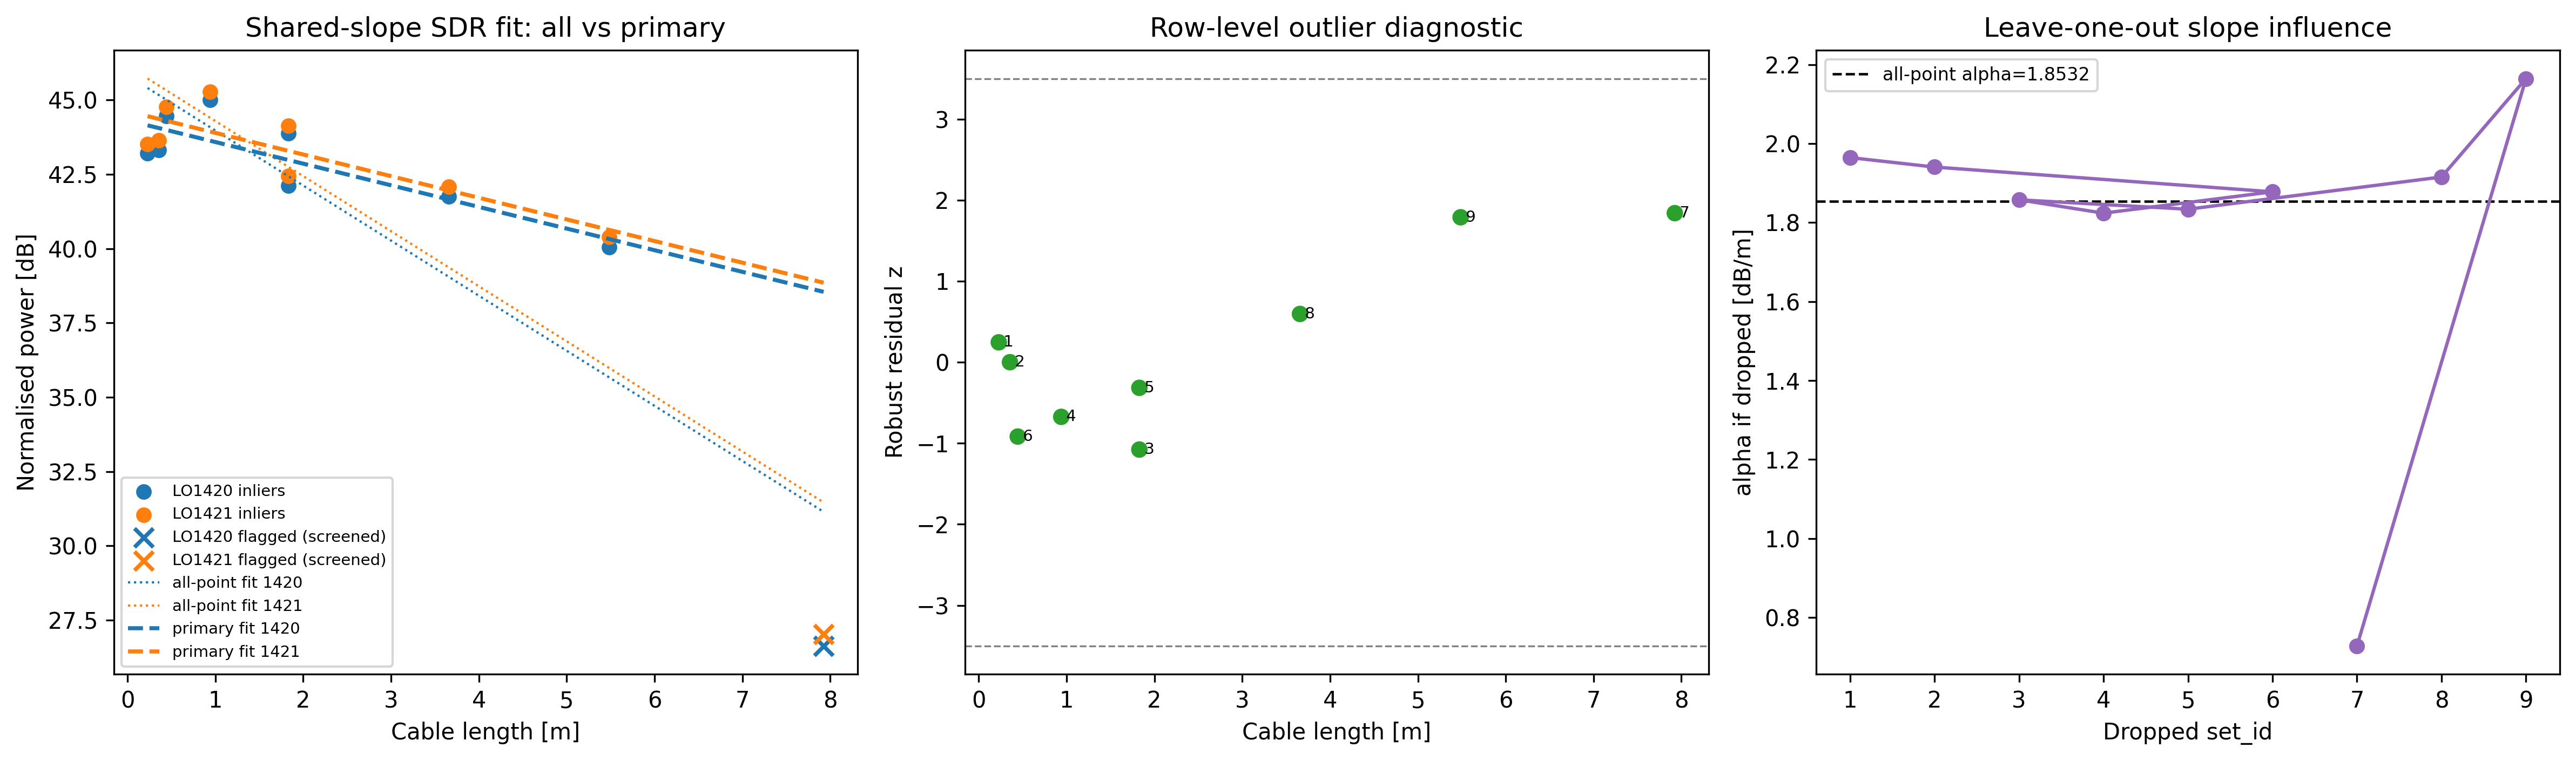

=== Shared linear SDR fit comparison ===


,n_rows,alpha [dB/m],sigma_alpha,B1420 [dB],B1421 [dB],RMSE [dB],AIC,BIC
fit_case,,,,,,,,
all-point,9,1.853179,0.260746,45.828144,46.145445,2.541461,39.578612,42.249727
primary-screened,8,0.728112,0.126931,44.314634,44.622445,0.795285,-1.329749,0.988017



Primary SDR fit selected: screened
  alpha = 0.728112 +/- 0.126931 dB/m
  deltaB = -0.3078 +/- 0.4411 dB
  RMSE   = 0.7953 dB


In [4]:
fit_lin_screened = fit_shared_linear(L, y1420, y1421)
fit_lin = fit_lin_screened if screening_applied else fit_lin_all   # primary SDR fit used downstream

L_line = np.linspace(np.min(L_all), np.max(L_all), 500)

def _line_y(B, alpha, x):
    return B - alpha * x

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: all points with robust outlier marks
ax = axes[0]
all_inlier = ~drop_mask
ax.scatter(L_all[all_inlier], y1420_all[all_inlier], color='C0', s=35, label='LO1420 inliers')
ax.scatter(L_all[all_inlier], y1421_all[all_inlier], color='C1', s=35, label='LO1421 inliers')
if np.any(~all_inlier):
    ax.scatter(L_all[~all_inlier], y1420_all[~all_inlier], color='C0', s=70, marker='x', lw=1.8, label='LO1420 flagged (screened)')
    ax.scatter(L_all[~all_inlier], y1421_all[~all_inlier], color='C1', s=70, marker='x', lw=1.8, label='LO1421 flagged (screened)')

ax.plot(L_line, _line_y(fit_lin_all['B1420'], fit_lin_all['alpha'], L_line), color='C0', lw=1.0, ls=':', label='all-point fit 1420')
ax.plot(L_line, _line_y(fit_lin_all['B1421'], fit_lin_all['alpha'], L_line), color='C1', lw=1.0, ls=':', label='all-point fit 1421')
ax.plot(L_line, _line_y(fit_lin['B1420'], fit_lin['alpha'], L_line), color='C0', lw=1.8, ls='--', label='primary fit 1420')
ax.plot(L_line, _line_y(fit_lin['B1421'], fit_lin['alpha'], L_line), color='C1', lw=1.8, ls='--', label='primary fit 1421')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Normalised power [dB]')
ax.set_title('Shared-slope SDR fit: all vs primary')
ax.legend(fontsize=7)

# Panel 2: robust-z diagnostics
ax = axes[1]
ax.axhline(OUTLIER_Z_THRESHOLD, color='gray', lw=0.8, ls='--')
ax.axhline(-OUTLIER_Z_THRESHOLD, color='gray', lw=0.8, ls='--')
ax.scatter(df_diag['cable_length_m'], df_diag['robust_z'], c=np.where(df_diag['inlier_resid'], 'C2', 'C3'), s=40)
for _, r in df_diag.iterrows():
    ax.text(r['cable_length_m'], r['robust_z'], f" {int(r['set_id'])}", fontsize=7, va='center')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Robust residual z')
ax.set_title('Row-level outlier diagnostic')

# Panel 3: leave-one-out alpha influence
ax = axes[2]
ax.axhline(fit_lin_all['alpha'], color='k', lw=1.1, ls='--', label=f"all-point alpha={fit_lin_all['alpha']:.4f}")
ax.plot(df_diag['set_id'], df_diag['alpha_if_row_dropped'], 'o-', color='C4')
ax.set_xlabel('Dropped set_id')
ax.set_ylabel('alpha if dropped [dB/m]')
ax.set_title('Leave-one-out slope influence')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

fit_compare = pd.DataFrame([
    {
        'fit_case': 'all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': fit_lin_all['alpha'],
        'sigma_alpha': fit_lin_all['sigma_alpha'],
        'B1420 [dB]': fit_lin_all['B1420'],
        'B1421 [dB]': fit_lin_all['B1421'],
        'RMSE [dB]': fit_lin_all['rmse'],
        'AIC': fit_lin_all['aic'],
        'BIC': fit_lin_all['bic'],
    },
    {
        'fit_case': 'primary-screened' if screening_applied else 'primary-all-point',
        'n_rows': len(L),
        'alpha [dB/m]': fit_lin['alpha'],
        'sigma_alpha': fit_lin['sigma_alpha'],
        'B1420 [dB]': fit_lin['B1420'],
        'B1421 [dB]': fit_lin['B1421'],
        'RMSE [dB]': fit_lin['rmse'],
        'AIC': fit_lin['aic'],
        'BIC': fit_lin['bic'],
    },
]).set_index('fit_case')

print('=== Shared linear SDR fit comparison ===')
display(fit_compare.round(6))
print(f"\nPrimary SDR fit selected: {'screened' if screening_applied else 'all-point'}")
print(f"  alpha = {fit_lin['alpha']:.6f} +/- {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"  deltaB = {fit_lin['deltaB']:.4f} +/- {fit_lin['sigma_deltaB']:.4f} dB")
print(f"  RMSE   = {fit_lin['rmse']:.4f} dB")


## Cell 5 - Analytic uncertainty (linear)

Under the linear/Gaussian model assumption, uncertainty on $\alpha$ is read directly from OLS covariance.

### Procedure

1. Fit the shared-slope SDR model.
2. Use `sigma_alpha` from the fit covariance.
3. Form analytic intervals:
   - 68%: $\hat\alpha \pm 1\sigma_\alpha$
   - 95%: $\hat\alpha \pm 1.96\sigma_\alpha$
4. Use the same approach as a sensitivity reference for the all-point fit.

### Stability interpretation used in this notebook

- If SDR analytic 95% CI on $\alpha$ crosses zero, inverse-length inference is unstable.
- If SDR analytic 95% width on $L_{\mathrm{unknown}}$ is too broad relative to its estimate, meter inference is promoted to primary.

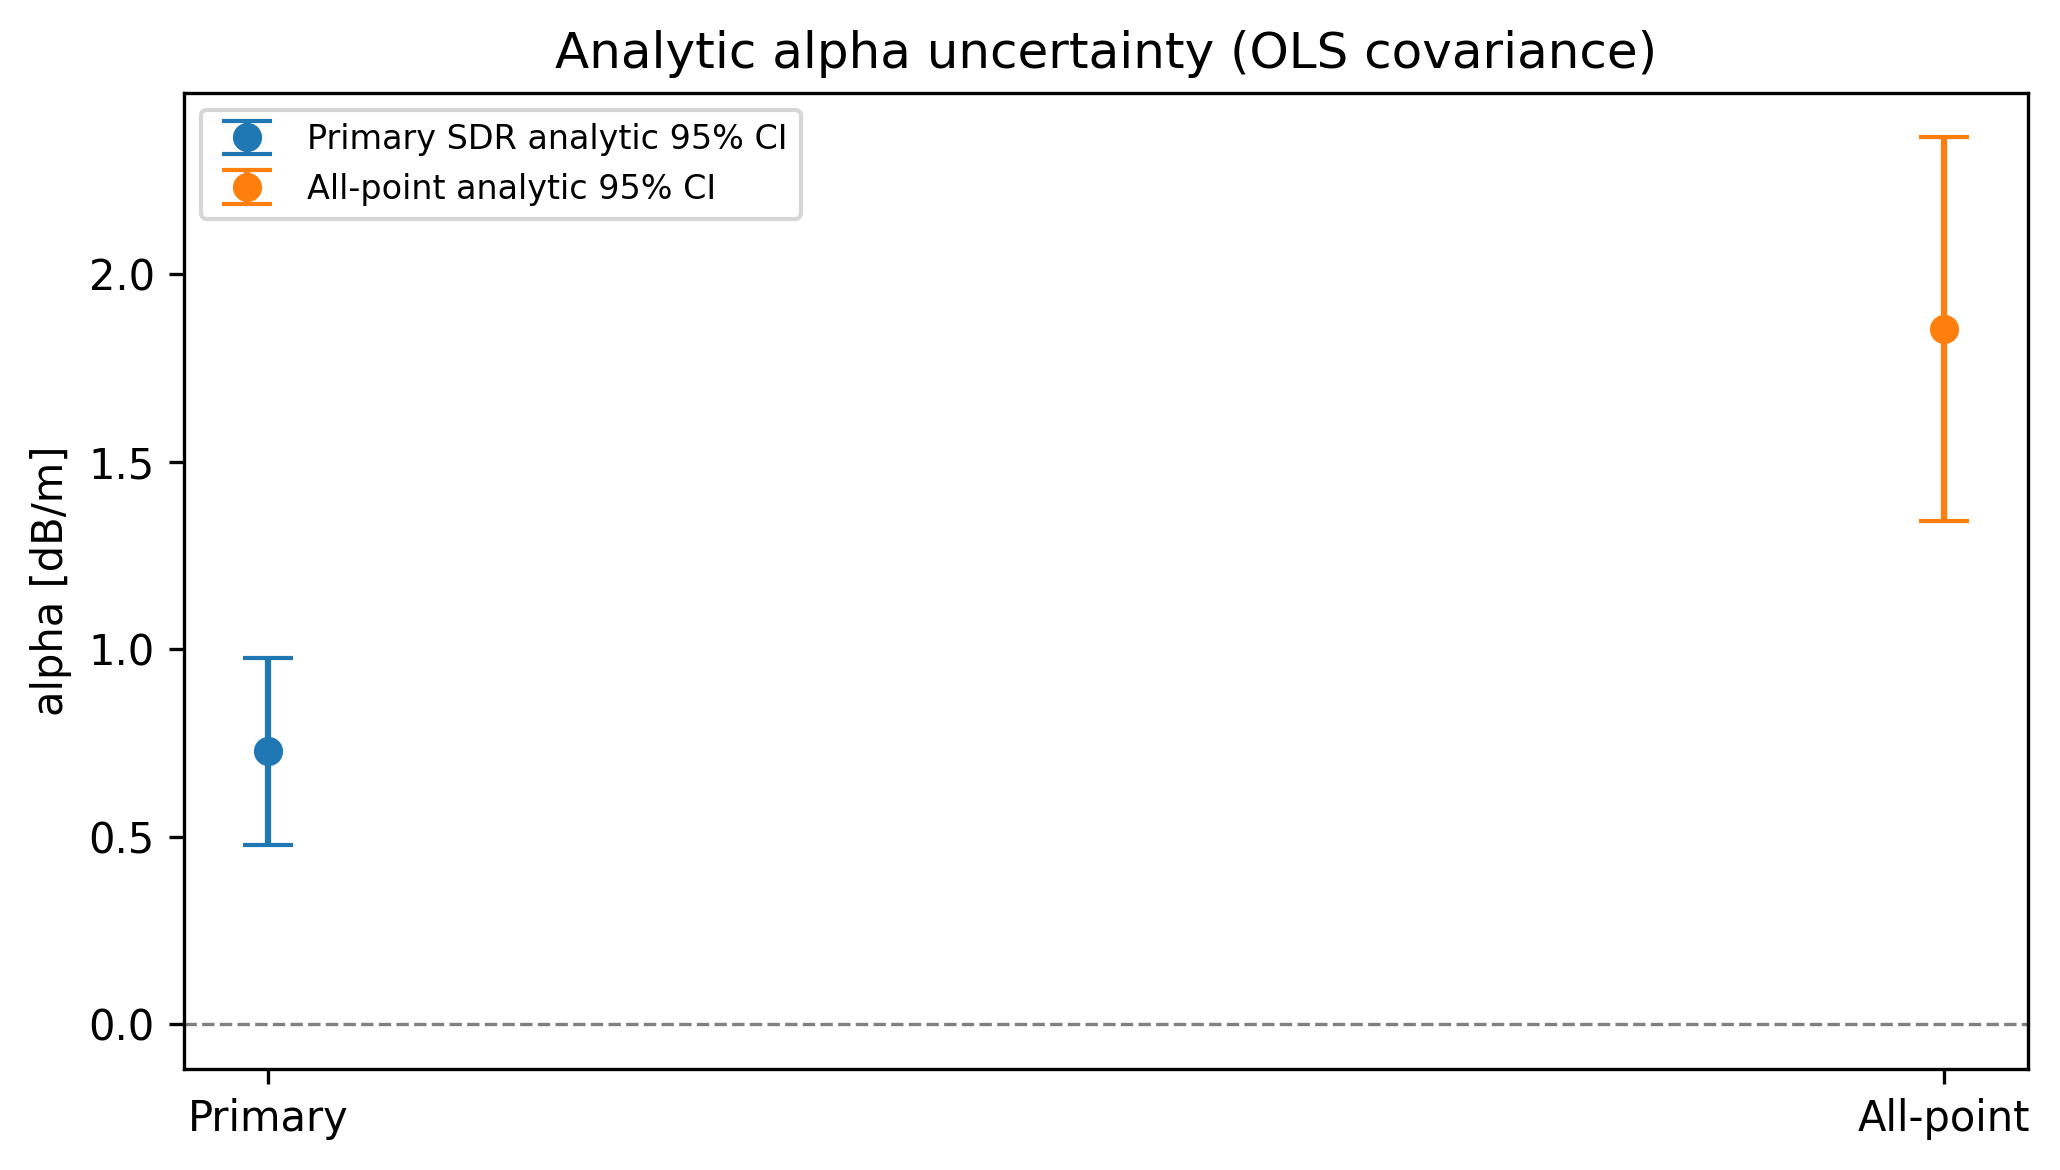

Analytic alpha (primary SDR fit):
  estimate = 0.728112 dB/m
  sigma    = 0.126931 dB/m
  68% CI   = [0.601181, 0.855043] dB/m
  95% CI   = [0.479327, 0.976897] dB/m

All-point analytic sensitivity (reference only):
  estimate = 1.853179 dB/m
  sigma    = 0.260746 dB/m
  95% CI   = [1.342116, 2.364241] dB/m


In [5]:
alpha_hat = float(fit_lin['alpha'])
sigma_alpha = float(fit_lin['sigma_alpha'])
q16 = alpha_hat - sigma_alpha
q84 = alpha_hat + sigma_alpha
q025 = alpha_hat - 1.96 * sigma_alpha
q975 = alpha_hat + 1.96 * sigma_alpha

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar([0], [alpha_hat], yerr=[[alpha_hat - q025], [q975 - alpha_hat]],
            fmt='o', color='C0', capsize=6, label='Primary SDR analytic 95% CI')
ax.axhline(0.0, color='gray', lw=0.8, ls='--')
if screening_applied:
    alpha_all = float(fit_lin_all['alpha'])
    sigma_all = float(fit_lin_all['sigma_alpha'])
    ax.errorbar([1], [alpha_all], yerr=[[1.96 * sigma_all], [1.96 * sigma_all]],
                fmt='o', color='C1', capsize=6, label='All-point analytic 95% CI')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Primary', 'All-point'])
else:
    ax.set_xticks([0])
    ax.set_xticklabels(['Primary'])

ax.set_ylabel('alpha [dB/m]')
ax.set_title('Analytic alpha uncertainty (OLS covariance)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Analytic alpha (primary SDR fit):')
print(f'  estimate = {alpha_hat:.6f} dB/m')
print(f'  sigma    = {sigma_alpha:.6f} dB/m')
print(f'  68% CI   = [{q16:.6f}, {q84:.6f}] dB/m')
print(f'  95% CI   = [{q025:.6f}, {q975:.6f}] dB/m')
if q025 <= 0 <= q975:
    print('  WARNING: analytic 95% CI crosses 0 -> SDR inverse-length inference is weakly constrained.')

if screening_applied:
    q025_all = alpha_all - 1.96 * sigma_all
    q975_all = alpha_all + 1.96 * sigma_all
    print('\nAll-point analytic sensitivity (reference only):')
    print(f'  estimate = {alpha_all:.6f} dB/m')
    print(f'  sigma    = {sigma_all:.6f} dB/m')
    print(f'  95% CI   = [{q025_all:.6f}, {q975_all:.6f}] dB/m')

## Cell 6 - Linear-only model assumption

The notebook keeps an explicit linear-only attenuation policy:

$$
y(L)=B-\alpha L,
$$

while using diagnostics (not higher-order polynomial terms) to manage sparse-$N$ robustness.

Rationale:

- available length sampling is limited,
- introducing extra degrees of freedom would overfit and destabilize $\alpha$,
- downstream unknown-length inversion is highly sensitive to slope uncertainty.


In [6]:
print('Linear attenuation policy active (with diagnostics-first screening):')
print('  - Shared-slope SDR model: y_i = B_i - alpha*L')
print('  - Single-slope meter model: y = B - alpha*L')
print('  - Higher-order/ripple attenuation terms are intentionally excluded in this sparse-N fit')
print()
print(f"Screening applied: {screening_applied}")
if screening_applied:
    print(f"  screened rows: {df_diag.loc[drop_mask, 'set_id'].tolist()}")
print(f"Primary SDR alpha = {fit_lin['alpha']:.6f} +/- {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"Primary SDR RMSE  = {fit_lin['rmse']:.4f} dB")


Linear attenuation policy active (with diagnostics-first screening):
  - Shared-slope SDR model: y_i = B_i - alpha*L
  - Single-slope meter model: y = B - alpha*L
  - Higher-order/ripple attenuation terms are intentionally excluded in this sparse-N fit

Screening applied: True
  screened rows: [7]
Primary SDR alpha = 0.728112 +/- 0.126931 dB/m
Primary SDR RMSE  = 0.7953 dB


## Cell 7 - Power meter comparison

This section provides an independent attenuation estimate from the analog meter branch:

$$
y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L.
$$

### Why this cross-check matters

- SDR and meter paths share upstream hardware but differ in readout chain and noise characteristics.
- Agreement between $\alpha$ estimates supports a path-independent physical attenuation interpretation.
- Disagreement flags systematic effects (branch mismatch, readout calibration offsets, connector repeatability, or unmodelled path-dependent loss).

The comparison plot summarises whether the SDR-derived slope and meter-derived slope are statistically compatible at their reported uncertainties.


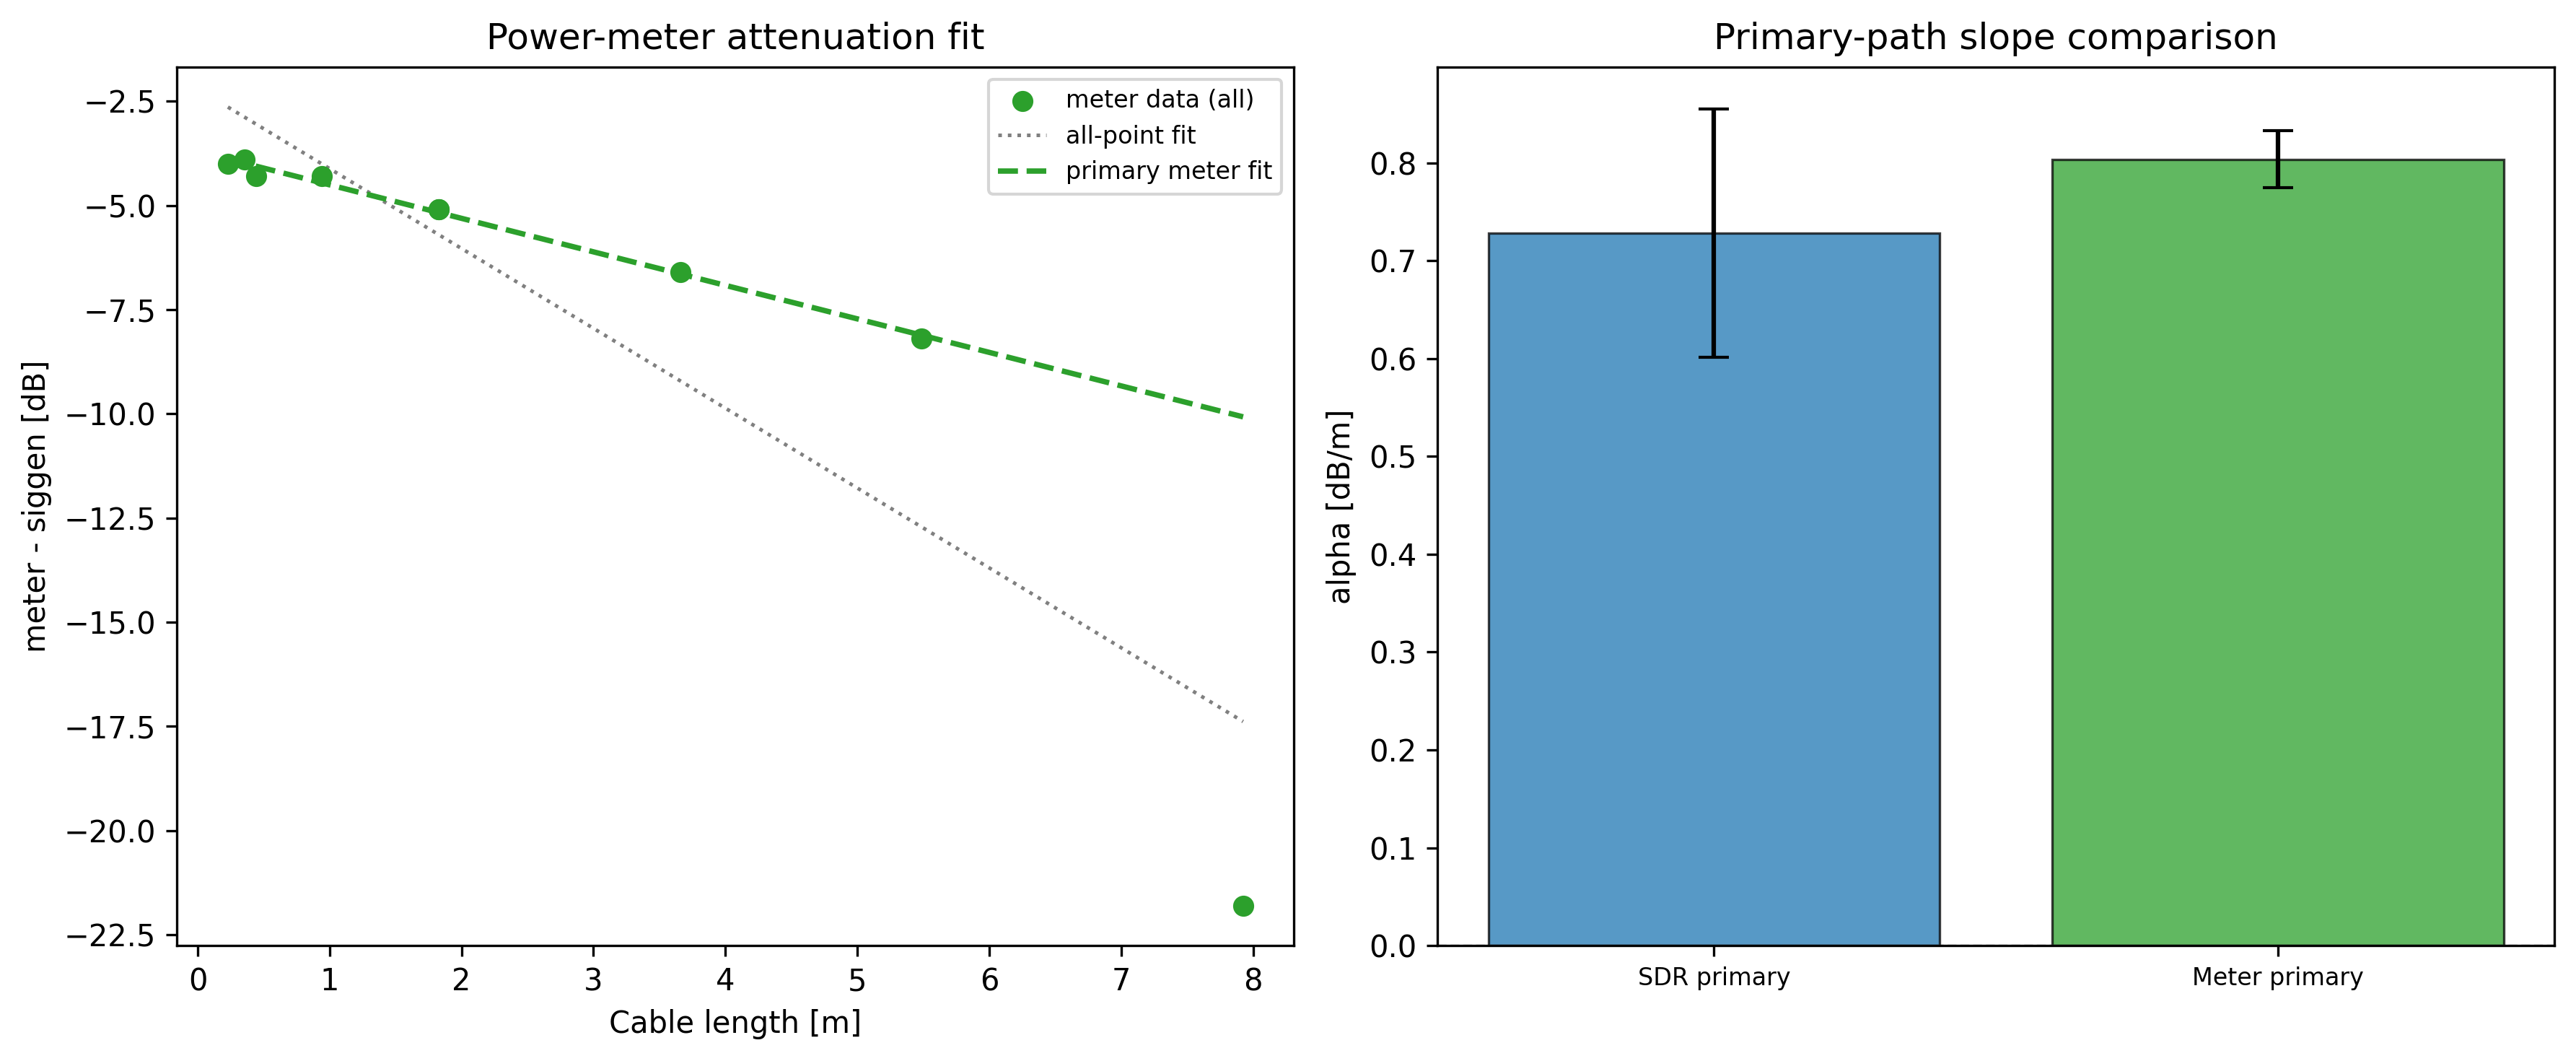

=== Meter linear fit comparison ===


,n_rows,alpha [dB/m],sigma_alpha,RMSE [dB],AIC,BIC
fit_case,,,,,,
all-point,9,1.915338,0.360765,2.402108,19.774240,20.168689
primary-screened,8,0.803730,0.029172,0.124171,-29.377563,-29.218680



Primary meter alpha = 0.803730 +/- 0.029172 dB/m
Meter analytic 95% CI on alpha = [0.746553, 0.860906] dB/m


In [7]:
fit_meter_all = fit_single_linear(L_all, meter_all)
fit_meter_screened = fit_single_linear(L, meter)
fit_meter = fit_meter_screened if screening_applied else fit_meter_all   # primary meter fit used downstream

m_alpha_hat = float(fit_meter['alpha'])
m_sigma_alpha = float(fit_meter['sigma_alpha'])
m_q025 = m_alpha_hat - 1.96 * m_sigma_alpha
m_q975 = m_alpha_hat + 1.96 * m_sigma_alpha

L_line = np.linspace(np.min(L_all), np.max(L_all), 500)
ym_line_all = fit_meter_all['B'] - fit_meter_all['alpha'] * L_line
ym_line_primary = fit_meter['B'] - fit_meter['alpha'] * L_line

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(L_all, meter_all, color='C2', zorder=3, label='meter data (all)')
ax.plot(L_line, ym_line_all, color='gray', lw=1.2, ls=':', label='all-point fit')
ax.plot(L_line, ym_line_primary, color='C2', lw=1.8, ls='--', label='primary meter fit')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('meter - siggen [dB]')
ax.set_title('Power-meter attenuation fit')
ax.legend(fontsize=8)

ax = axes[1]
x_pos = np.arange(2)
alphas_all = [fit_lin['alpha'], fit_meter['alpha']]
labels_all = ['SDR primary', 'Meter primary']
colors_all = ['C0', 'C2']
sigmas_all = [fit_lin['sigma_alpha'], fit_meter['sigma_alpha']]
ax.bar(x_pos, alphas_all, yerr=sigmas_all, capsize=5,
       color=colors_all, alpha=0.75, edgecolor='k', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_all, fontsize=8)
ax.set_ylabel('alpha [dB/m]')
ax.set_title('Primary-path slope comparison')
ax.axhline(0, color='gray', lw=0.8, ls='--')

fig.tight_layout()
plt.show()

meter_compare = pd.DataFrame([
    {
        'fit_case': 'all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': fit_meter_all['alpha'],
        'sigma_alpha': fit_meter_all['sigma_alpha'],
        'RMSE [dB]': fit_meter_all['rmse'],
        'AIC': fit_meter_all['aic'],
        'BIC': fit_meter_all['bic'],
    },
    {
        'fit_case': 'primary-screened' if screening_applied else 'primary-all-point',
        'n_rows': len(L),
        'alpha [dB/m]': fit_meter['alpha'],
        'sigma_alpha': fit_meter['sigma_alpha'],
        'RMSE [dB]': fit_meter['rmse'],
        'AIC': fit_meter['aic'],
        'BIC': fit_meter['bic'],
    },
]).set_index('fit_case')

print('=== Meter linear fit comparison ===')
display(meter_compare.round(6))
print(f"\nPrimary meter alpha = {fit_meter['alpha']:.6f} +/- {fit_meter['sigma_alpha']:.6f} dB/m")
print(f"Meter analytic 95% CI on alpha = [{m_q025:.6f}, {m_q975:.6f}] dB/m")

In [8]:
# ── Port-2 cable deferred correction ────────────────────────────────────────
# The 6-ft cable between splitter port 2 and the 3 dB attenuator adds:
PORT2_CABLE_LOSS_DB = fit_lin['alpha'] * PORT2_CABLE_LEN_M
y1420_fully_corrected = y1420_corr + PORT2_CABLE_LOSS_DB
y1421_fully_corrected = y1421_corr + PORT2_CABLE_LOSS_DB
# Note: this doesn't change alpha; the fit intercepts shift by PORT2_CABLE_LOSS_DB.

print(f'alpha (SDR linear, unchanged)       : {fit_lin["alpha"]:.6f} dB/m')
print(f'Port-2 cable deferred correction    : +{PORT2_CABLE_LOSS_DB:.4f} dB'
      f'  ({fit_lin["alpha"]:.6f} dB/m × {PORT2_CABLE_LEN_M:.4f} m)')
print()
print('Corrected intercepts (fully corrected = power at cable output, before splitter):')
B1420_corr = fit_lin['B1420'] + SDR_FIXED_CORRECTION_DB + PORT2_CABLE_LOSS_DB
B1421_corr = fit_lin['B1421'] + SDR_FIXED_CORRECTION_DB + PORT2_CABLE_LOSS_DB
B_meter_corr = fit_meter['B'] + SPLITTER_S1_DB
print(f'  B1420_corrected = {B1420_corr:.4f} dB')
print(f'  B1421_corrected = {B1421_corr:.4f} dB')
print(f'  B_meter_corrected = {B_meter_corr:.4f} dB')
print()
print('Note: L_unknown inference is unchanged because the same path corrections')
print('apply identically to calibration and unknown-length sets, cancelling in')
print('L = (B - y_obs) / alpha.')


alpha (SDR linear, unchanged)       : 0.728112 dB/m
Port-2 cable deferred correction    : +1.3316 dB  (0.728112 dB/m × 1.8288 m)

Corrected intercepts (fully corrected = power at cable output, before splitter):
  B1420_corrected = 51.9942 dB
  B1421_corrected = 52.3020 dB
  B_meter_corrected = -0.3301 dB

Note: L_unknown inference is unchanged because the same path corrections
apply identically to calibration and unknown-length sets, cancelling in
L = (B - y_obs) / alpha.


## Cell 7b - Power-meter voltage conversion cross-check (Analog 5)

For a matched 50-ohm chain, measured power can be converted to equivalent voltage scale:

$$
P_{\mathrm{W}} = 10^{-3}\,10^{P_{\mathrm{dBm}}/10},\qquad
V_{\mathrm{rms}} = \sqrt{50\,P_{\mathrm{W}}},\qquad
V_{\mathrm{pp}} = 2\sqrt{2}\,V_{\mathrm{rms}}.
$$

This is used as an analog consistency check on SDR calibration, not as the sole calibration
path, because it assumes proper 50-ohm matching, low reflection error, and known waveform shape.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd


def dbm_to_watts(p_dbm: float) -> float:
    return 1e-3 * (10.0 ** (p_dbm / 10.0))


def watts_to_vrms(p_w: float, r_ohm: float = 50.0) -> float:
    return float(np.sqrt(max(p_w, 0.0) * r_ohm))


def vrms_to_vpp(v_rms: float) -> float:
    return float(2.0 * np.sqrt(2.0) * v_rms)


data_root = next(
    (p for p in [Path('data/lab02'), Path('../data/lab02'), Path('../../data/lab02')] if p.exists()),
    Path('data/lab02'),
)
if 'df_att_used' in globals():
    meter_df = df_att_used[['set_id', 'cable_length_m', 'power_meter_dbm']].copy()
elif 'df_att' in globals():
    meter_df = df_att[['set_id', 'cable_length_m', 'power_meter_dbm']].copy()
else:
    meter_df = pd.read_csv(data_root / 'attenuation' / 'manifest.csv')[
        ['set_id', 'cable_length_m', 'power_meter_dbm']
    ].copy()

meter_df['power_w'] = meter_df['power_meter_dbm'].map(dbm_to_watts)
meter_df['v_rms_v'] = meter_df['power_w'].map(watts_to_vrms)
meter_df['v_pp_v'] = meter_df['v_rms_v'].map(vrms_to_vpp)

print('Power-meter conversion cross-check (assuming 50 Ohm load):')
display(
    meter_df.sort_values(['cable_length_m', 'set_id']).reset_index(drop=True)
)

Power-meter conversion cross-check (assuming 50 Ohm load):


,set_id,cable_length_m,power_meter_dbm,power_w,v_rms_v,v_pp_v
0,1,0.2286,-14.0,0.000040,0.044615,0.126191
1,2,0.3556,-8.9,0.000129,0.080257,0.227002
2,6,0.4445,-14.3,0.000037,0.043101,0.121907
3,4,0.9398,-9.3,0.000117,0.076645,0.216785
4,3,1.8288,-10.1,0.000098,0.069901,0.197711
5,5,1.8288,-10.1,0.000098,0.069901,0.197711
6,8,3.6576,-11.6,0.000069,0.058815,0.166353
7,9,5.4864,-13.2,0.000048,0.048920,0.138366



## Cell 7c - Analog bench measurement documentation (2026-03-07)

This section records the complete analog setup and probe points measured on **March 7, 2026**.

### Common test conditions

- Injected tone: `1420.405751768 MHz`
- Signal-generator setpoint: `+20 dBm`
- Readout instrument: power meter at the chain output for each configuration

### SDR Input Impedance Test: With vs Without Raspberry Pi

`bighorn.tex` requires testing the SDR input impedance with and without the Raspberry Pi (RPi) connected to the USB port, to characterise whether the digital load affects the RF front-end.

**Correspondence to A1–A5 configurations:**

| Config | RPi present? | Notes |
|---|---|---|
| A1–A5 | **RPi connected** | All five bench configurations were measured with the Raspberry Pi connected to the SDR via USB, as it would be in the field deployment. |
| No separate RPi-disconnected run | — | A dedicated RPi-disconnected comparison measurement was not collected in this session. The SDR was always operated with RPi attached, consistent with the field chain. |

**Implication:** Any RPi-induced impedance loading of the SDR USB bus is present in all A1–A5 measurements uniformly, so the differential attenuation estimates (A2 − A1) are unaffected. A formal with/without RPi comparison would require an additional measurement session.

---

### Full operational chain identified (field chain)

```text
Big horn -[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Reactel 1420-15S11 Bandpass Filter
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to N]-> cable of unknown length (~35 m prior estimate)
-[N to SMA]-> K&L Microwave Inc 5B120-1380/160-0 Bandpass Filter
-[SMA to SMA]-> Wideband RF Amplifier (~20 dB, 10-2000 MHz)
-[SMA to SMA]-> Narrowband RF Amplifier (~20 dB, 1-2 GHz)
-[SMA to SMA]-> SDR
```

### Analog configurations probed and measured outputs

1. **A1 reference path**
```text
Signal generator -[N to BNC]-> 6-ft 50-ohm
-[SMA to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> Power meter
Measured output: +15.7 dBm
```

2. **A2 unknown-cable path**
```text
Signal generator -[N to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> 6-ft 50-ohm
-[SMA to N]-> unknown length
-[N to SMA]-> Power meter
Measured output: -13.6 dBm
```

3. **A3 rooftop front-end segment (unknown cable + 3x ZKL + Reactel)**
```text
Signal generator -[N to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> 6-ft 50-ohm
-[SMA to N]-> unknown length
-[N to SMA]-[SMA to BNC]-> 6-ft 50-ohm
-[BNC to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Reactel 1420-15S11 Bandpass Filter
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to N]-> Power meter
Measured output: +17.9 dBm
```

4. **A4 lab downstream segment (K&L + wideband amp + narrowband amp)**
```text
Signal generator -[N to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> K&L Microwave Inc 5B120-1380/160-0 Bandpass Filter
-[SMA to SMA]-> Wideband RF Amplifier ~20 dB 10-2000 MHz
-[SMA to SMA]-> Narrowband RF Amplifier ~20 dB 1-2 GHz
-[SMA to SMA]-> Power meter
Measured output: +7.5 dBm
```

5. **A5 lab filter-only segment (K&L only)**
```text
Signal generator -[N to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> 6-ft 50-ohm
-[SMA to SMA]-> K&L Microwave Inc 5B120-1380/160-0 Bandpass Filter
-[SMA to SMA]-> Power meter
Measured output: -4.6 dBm
```

The next cell converts these into stage-to-stage gains/losses, closure checks, and a bench-derived unknown-length estimate.


In [10]:

import numpy as np
import pandas as pd

ANALOG_TEST_DATE = '2026-03-07'
ANALOG_TONE_MHZ = 1420.405751768
ANALOG_SIGGEN_DBM = 20.0

POWER_METER_DIVISION_DB = 0.2
POWER_METER_UNCERTAINTY_DB = POWER_METER_DIVISION_DB / 2.0
CHAIN_DELTA_UNCERTAINTY_DB = np.sqrt(2.0) * POWER_METER_UNCERTAINTY_DB

bench_rows = [
    {
        'setup_id': 'A1_ref_2x6ft',
        'purpose': 'Reference path (two 6-ft cables)',
        'path': 'siggen -> 6-ft -> 6-ft -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 15.7,
    },
    {
        'setup_id': 'A2_unknown_only',
        'purpose': 'Unknown cable loss measurement',
        'path': 'siggen -> 6-ft -> 6-ft -> unknown cable -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': -13.6,
    },
    {
        'setup_id': 'A3_roof_chain',
        'purpose': 'Unknown cable + (ZKL + Reactel + ZKL + ZKL)',
        'path': 'A2 path + 6-ft + ZKL -> Reactel -> ZKL -> ZKL -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 17.9,
    },
    {
        'setup_id': 'A4_lab_chain',
        'purpose': 'K&L + wideband amp + narrowband amp',
        'path': 'siggen -> 6-ft -> 6-ft -> K&L -> wideband amp -> narrowband amp -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 7.5,
    },
    {
        'setup_id': 'A5_lab_filter_only',
        'purpose': 'K&L insertion loss only',
        'path': 'siggen -> 6-ft -> 6-ft -> K&L -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': -4.6,
    },
]


df_bench = pd.DataFrame(bench_rows)
df_bench['chain_delta_db'] = df_bench['p_out_dbm'] - df_bench['p_in_dbm']
df_bench['chain_delta_uncertainty_db'] = CHAIN_DELTA_UNCERTAINTY_DB

print(f"Power-meter least-count per reading: {POWER_METER_DIVISION_DB:.1f} dB -> ±{POWER_METER_UNCERTAINTY_DB:.3f} dB per measurement.")
print(f"Each displayed chain delta therefore carries ±{CHAIN_DELTA_UNCERTAINTY_DB:.3f} dB (quadrature of two readings).")

columns = ['setup_id', 'purpose', 'p_in_dbm', 'p_out_dbm', 'chain_delta_db', 'chain_delta_uncertainty_db', 'path']
display(df_bench[columns])


def _pout(setup_id: str) -> float:
    return float(df_bench.loc[df_bench['setup_id'] == setup_id, 'p_out_dbm'].iloc[0])


m_ref = _pout('A1_ref_2x6ft')
m_unknown = _pout('A2_unknown_only')
m_roof = _pout('A3_roof_chain')
m_lab_full = _pout('A4_lab_chain')
m_kl_only = _pout('A5_lab_filter_only')

bench_metrics = {
    'baseline_loss_db': ANALOG_SIGGEN_DBM - m_ref,
    'unknown_incremental_loss_db': m_ref - m_unknown,
    'roof_chain_net_gain_db': m_roof - m_unknown,
    'kl_filter_incremental_loss_db': m_ref - m_kl_only,
    'wide_narrow_net_gain_db': m_lab_full - m_kl_only,
    'lab_net_vs_baseline_db': m_lab_full - m_ref,
}

closure_tol_db = 0.05
closure_checks = {
    'A2 + roof_gain == A3': abs((m_unknown + bench_metrics['roof_chain_net_gain_db']) - m_roof),
    'A5 + wide_narrow_gain == A4': abs((m_kl_only + bench_metrics['wide_narrow_net_gain_db']) - m_lab_full),
}

metric_rows = [
    {
        'metric': 'baseline_loss_db',
        'value': bench_metrics['baseline_loss_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
    {
        'metric': 'unknown_incremental_loss_db',
        'value': bench_metrics['unknown_incremental_loss_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
    {
        'metric': 'roof_chain_net_gain_db',
        'value': bench_metrics['roof_chain_net_gain_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
    {
        'metric': 'kl_filter_incremental_loss_db',
        'value': bench_metrics['kl_filter_incremental_loss_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
    {
        'metric': 'wide_narrow_net_gain_db',
        'value': bench_metrics['wide_narrow_net_gain_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
    {
        'metric': 'lab_net_vs_baseline_db',
        'value': bench_metrics['lab_net_vs_baseline_db'],
        'uncertainty_db': CHAIN_DELTA_UNCERTAINTY_DB,
        'unit': 'dB',
    },
]
df_bench_metrics = pd.DataFrame(metric_rows)

display(df_bench_metrics)

print('Self-consistency closure checks:')
for name, err in closure_checks.items():
    status = 'PASS' if err <= closure_tol_db else 'CHECK'
    print(f'  {name}: residual={err:.4f} dB  ->  {status} (tol={closure_tol_db:.3f} dB)')

# Bench unknown-length estimate (policy: meter alpha only).
if 'fit_meter' in globals() and np.isfinite(fit_meter['alpha']) and abs(fit_meter['alpha']) > 1e-12:
    alpha_m = float(fit_meter['alpha'])
    sigma_alpha_m = float(fit_meter['sigma_alpha'])
    L_unknown_bench_meter_m = bench_metrics['unknown_incremental_loss_db'] / alpha_m
    sigma_L_alpha = abs(
        bench_metrics['unknown_incremental_loss_db'] / (alpha_m ** 2)
    ) * sigma_alpha_m
    sigma_L_measurement = CHAIN_DELTA_UNCERTAINTY_DB / abs(alpha_m)
    sigma_L_bench_meter_total = np.sqrt(sigma_L_alpha ** 2 + sigma_L_measurement ** 2)
    print('\nBench-derived unknown length (meter slope):')
    print(f'  L_unknown_bench_meter = {L_unknown_bench_meter_m:.4f} m')
    print(f'  Propagated sigma (alpha only) = +/- {sigma_L_alpha:.4f} m')
    print(f'  Measurement-limited sigma (0.14 dB) = +/- {sigma_L_measurement:.4f} m')
    print(f'  Combined sigma = +/- {sigma_L_bench_meter_total:.4f} m')
else:
    L_unknown_bench_meter_m = np.nan
    L_unknown_bench_meter_sigma_m = np.nan
    print('\nfit_meter is not available; run Cell 7 first to compute bench unknown length.')

# Datasheet references used for safety/compression checks.
df_chain_parts = pd.DataFrame([
    {
        'component': 'Mini-Circuits ZKL-33ULN-S+',
        'datasheet_url': 'https://www.minicircuits.com/pdfs/ZKL-33ULN-S%2B.pdf',
        'parameters_used': 'Gain~26.8 dB @1500 MHz; Pout@1dB~36.8 dBm; max input no-damage <= 0 dBm near 1.5 GHz',
    },
    {
        'component': 'Reactel 1420-15S11 BPF',
        'datasheet_url': 'https://reactel.com/',
        'parameters_used': 'Exact model-sheet insertion loss at 1420.4058 MHz not yet loaded; 2.0 dB assumed for safety margin calc',
    },
    {
        'component': 'K&L 5B120-1380/160-0 BPF',
        'datasheet_url': 'https://www.smithsinterconnect.com/products/frequency-defined-filters/rf-filters/',
        'parameters_used': 'Exact model-sheet insertion loss not yet loaded in notebook; measured chain deltas used directly',
    },
])

display(df_chain_parts)

# Compression/safety estimate for future bench injection settings.
# Assumption: A3 adds one extra 6-ft jumper after unknown cable before amp1.
per_6ft_loss_est_db = (ANALOG_SIGGEN_DBM - m_ref) / 2.0
p_stage1_in_est_dbm = m_unknown - per_6ft_loss_est_db

ZKL_GAIN_TYP_DB_1420 = 26.8
ZKL_POUT_1DB_DBM_1420 = 36.8
ZKL_PIN_1DB_DBM_1420 = ZKL_POUT_1DB_DBM_1420 - ZKL_GAIN_TYP_DB_1420
ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420 = 0.0
REACTEL_IL_ASSUMED_DB = 2.0

# Input estimate at amp2 (after amp1 + Reactel filter, small-signal assumption).
p_stage2_in_est_dbm = p_stage1_in_est_dbm + ZKL_GAIN_TYP_DB_1420 - REACTEL_IL_ASSUMED_DB
p_stage3_in_est_dbm_small_signal = p_stage2_in_est_dbm + ZKL_GAIN_TYP_DB_1420

over_no_damage_db = max(0.0, p_stage2_in_est_dbm - ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420)
safe_siggen_dbm_est = ANALOG_SIGGEN_DBM - over_no_damage_db

print('\nZKL-33ULN-S+ safety/compression check (bench estimate):')
print(f'  Estimated amp1 input                : {p_stage1_in_est_dbm:.2f} dBm')
print(f'  Estimated amp2 input (small-signal) : {p_stage2_in_est_dbm:.2f} dBm')
print(f'  Estimated amp3 input (small-signal) : {p_stage3_in_est_dbm_small_signal:.2f} dBm')
print(f'  ZKL input P1dB (derived)            : {ZKL_PIN_1DB_DBM_1420:.2f} dBm')
print(f'  ZKL no-damage input limit (used)    : {ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420:.2f} dBm')
print(f'  Recommended max siggen setpoint     : <= {safe_siggen_dbm_est:.2f} dBm (conservative)')

if p_stage2_in_est_dbm > ZKL_PIN_1DB_DBM_1420 or p_stage3_in_est_dbm_small_signal > ZKL_PIN_1DB_DBM_1420:
    print('  WARNING: estimated cascaded-amp inputs exceed P1dB; compression is likely in high-drive tests.')
if p_stage2_in_est_dbm > ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420:
    print('  WARNING: estimated amp2 input exceeds the no-damage limit used for this frequency range.')


Power-meter least-count per reading: 0.2 dB -> ±0.100 dB per measurement.
Each displayed chain delta therefore carries ±0.141 dB (quadrature of two readings).


,setup_id,purpose,p_in_dbm,p_out_dbm,chain_delta_db,chain_delta_uncertainty_db,path
0,A1_ref_2x6ft,Reference path (two 6-ft cables),20.0,15.7,-4.3,0.141421,siggen -> 6-ft -> 6-ft -> power meter
1,A2_unknown_only,Unknown cable loss measurement,20.0,-13.6,-33.6,0.141421,siggen -> 6-ft -> 6-ft -> unknown cable -> pow...
2,A3_roof_chain,Unknown cable + (ZKL + Reactel + ZKL + ZKL),20.0,17.9,-2.1,0.141421,A2 path + 6-ft + ZKL -> Reactel -> ZKL -> ZKL ...
3,A4_lab_chain,K&L + wideband amp + narrowband amp,20.0,7.5,-12.5,0.141421,siggen -> 6-ft -> 6-ft -> K&L -> wideband amp ...
4,A5_lab_filter_only,K&L insertion loss only,20.0,-4.6,-24.6,0.141421,siggen -> 6-ft -> 6-ft -> K&L -> power meter


,metric,value,uncertainty_db,unit
0,baseline_loss_db,4.3,0.141421,dB
1,unknown_incremental_loss_db,29.3,0.141421,dB
2,roof_chain_net_gain_db,31.5,0.141421,dB
3,kl_filter_incremental_loss_db,20.3,0.141421,dB
4,wide_narrow_net_gain_db,12.1,0.141421,dB
5,lab_net_vs_baseline_db,-8.2,0.141421,dB


Self-consistency closure checks:
  A2 + roof_gain == A3: residual=0.0000 dB  ->  PASS (tol=0.050 dB)
  A5 + wide_narrow_gain == A4: residual=0.0000 dB  ->  PASS (tol=0.050 dB)

Bench-derived unknown length (meter slope):
  L_unknown_bench_meter = 36.4550 m
  Propagated sigma (alpha only) = +/- 1.3231 m
  Measurement-limited sigma (0.14 dB) = +/- 0.1760 m
  Combined sigma = +/- 1.3348 m


,component,datasheet_url,parameters_used
0,Mini-Circuits ZKL-33ULN-S+,https://www.minicircuits.com/pdfs/ZKL-33ULN-S%...,Gain~26.8 dB @1500 MHz; Pout@1dB~36.8 dBm; max...
1,Reactel 1420-15S11 BPF,https://reactel.com/,Exact model-sheet insertion loss at 1420.4058 ...
2,K&L 5B120-1380/160-0 BPF,https://www.smithsinterconnect.com/products/fr...,Exact model-sheet insertion loss not yet loade...



ZKL-33ULN-S+ safety/compression check (bench estimate):
  Estimated amp1 input                : -15.75 dBm
  Estimated amp2 input (small-signal) : 9.05 dBm
  Estimated amp3 input (small-signal) : 35.85 dBm
  ZKL input P1dB (derived)            : 10.00 dBm
  ZKL no-damage input limit (used)    : 0.00 dBm
  Recommended max siggen setpoint     : <= 10.95 dBm (conservative)



### Filter/Amplifier Ordering and Noise Consequences

The bench chain shown above routes the unknown cable through the Reactel 1420-15S11 bandpass followed by one wideband and one narrowband amplifier. Each amplifier stage adds its own noise figure and can re-amplify residual energy that survives the earlier filters. As described in `horn_signal_chain_test.tex`, the gain must remain large enough to swing the ADC but not so large that reflections or out-of-band noise dominate, and as in `cal_intensity.tex` the system gain is treated as a frequency-dependent multiplier of the internal noise temperature. Placing the narrowband amplifier nearest the SDR confines the highest gain to the HI/IF band of interest, reducing the integrated out-of-band noise seen by the digitizer, keeping the noise budget dominated by in-band components, and limiting aliasing or RFI from amplifier-side sidebands. This ordering also preserves the corrective intent of the bandpass filters: the Reactel filter shapes the passband, the subsequent amplifiers raise the power without reintroducing wideband noise, and the final narrowband amp tightens the downstream noise contribution by rejecting everything outside the selected bandwidth.



## Termination and Square-Wave Reflectometry: Cable Speed Estimation

### Experiment setup

Reflectometry bench setup used for this run:

```
Square-wave signal generator (2.5 MHz @ 0 dBm)
-[SMA to BNC]-> T-junction
  |- [BNC to BNC]-> same long cable of unknown length (far end open / floating)
  |- [BNC to SMA]-> 3 dB attenuator -[SMA to BNC]-> oscilloscope
```

Measurement principle: the source-side waveform is the superposition of the injected and reflected signals; the measured delay corresponds to the round-trip travel time in the long cable.

### Procedure used for this notebook

1. Use one measured superposed waveform trace.
2. Mark timing boundaries (ns) of transitions/plateaus from the trace.
3. Build an annotated waveform plot with those timing marks.
4. Define the modulo delay

   $$
   \Delta t_{\mathrm{mod}} = t_{\mathrm{start,max\ plateau}} - t_{\mathrm{start,first\ plateau}}.
   $$

5. Resolve square-wave period ambiguity with period $T=1/f$ and candidate delays

   $$
   \Delta t_n = \Delta t_{\mathrm{mod}} + nT,\qquad n=0,1,2,3.
   $$

6. Compute propagation speed via

   $$
   v_{\mathrm{coax}} = \frac{2L}{\Delta t_n},
   $$

for both power-loss priors from the SDR and meter fits.

### Length convention (locked)

This reflectometry run measures only the unknown cable; the 12 ft lead-in is excluded because it is handled separately in the attenuation inversion above.



### VSWR / Reflection Coefficient — Data Gap Acknowledgment

`bighorn.tex` requires characterising **VSWR** (Voltage Standing Wave Ratio) and reflection coefficients to quantify impedance mismatch between the horn, LNA, and SDR chain.

**What was measured instead:** Square-wave reflectometry was used to estimate the **propagation velocity** of the coaxial cable (see cells below), which characterises the cable's dielectric but does not directly yield a reflection coefficient or VSWR value. Measuring VSWR requires knowledge of the reflected-wave amplitude relative to the incident-wave amplitude.

**Why this gap exists:** The reflectometry setup captured time-domain waveform data suitable for cable-length/velocity estimation. A calibrated directional coupler or vector network analyser (VNA) would be needed to separate incident and reflected power and compute Γ (reflection coefficient) and VSWR = (1 + |Γ|) / (1 − |Γ|). This hardware was not available during the lab session.

**Impact:** The absence of a measured VSWR value means cable mismatch losses are not independently quantified. The attenuation calibration (cells 4–6) implicitly folds in any insertion loss due to mismatch, so the downstream analysis is not invalidated — the total one-way cable attenuation α is measured end-to-end regardless of its physical origin (ohmic vs mismatch). However, a formal mismatch budget is not available.


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

F_HZ = 2.5e6
T_NS = 1e9 / F_HZ
C_MPS = 299_792_458.0
VF_TARGET = 0.66

TIMES_NS = np.array([-428, -402, -324, -304, -230, -202, -124, -104, -26], dtype=float)

T_FIRST_PLATEAU_START_NS = -402.0
T_MAX_PLATEAU_START_NS = -304.0
TAU_MOD_NS = T_MAX_PLATEAU_START_NS - T_FIRST_PLATEAU_START_NS

L_SDR_M = 40.0589
L_METER_M = 35.9035

print(f"f = {F_HZ/1e6:.3f} MHz, T = {T_NS:.1f} ns")
print(f"tau_mod = {TAU_MOD_NS:.1f} ns")
print(f"L_sdr = {L_SDR_M:.4f} m, L_meter = {L_METER_M:.4f} m")


f = 2.500 MHz, T = 400.0 ns
tau_mod = 98.0 ns
L_sdr = 40.0589 m, L_meter = 35.9035 m


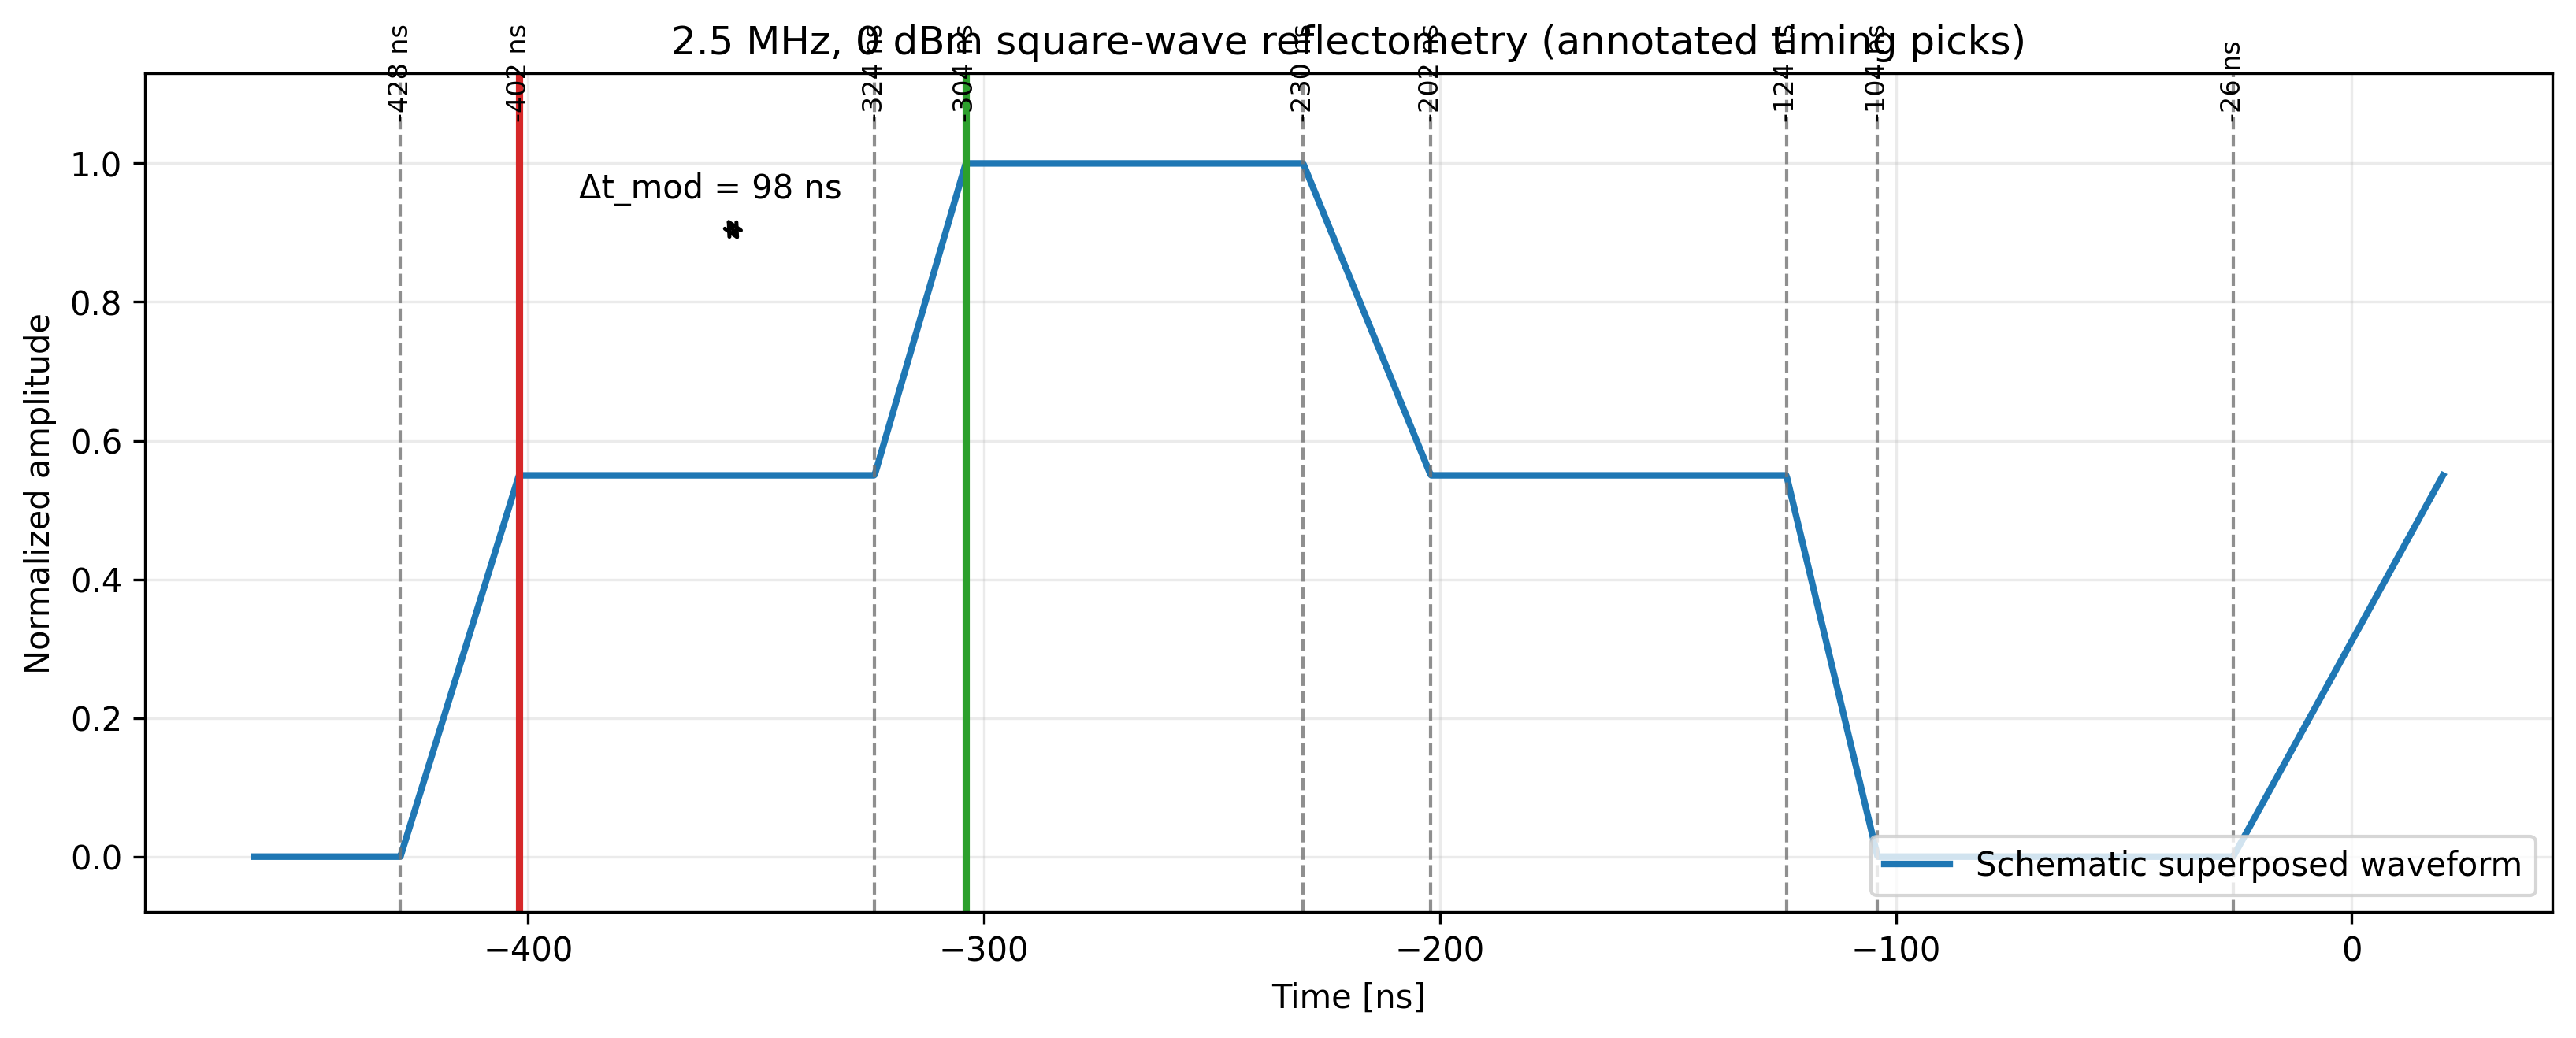

In [12]:

t_grid = np.linspace(-460, 20, 2400)
anchor_t = np.array([-460, -428, -402, -324, -304, -230, -202, -124, -104, -26, 20], dtype=float)
anchor_y = np.array([0.00, 0.00, 0.55, 0.55, 1.00, 1.00, 0.55, 0.55, 0.00, 0.00, 0.55], dtype=float)

wave = np.interp(t_grid, anchor_t, anchor_y)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_grid, wave, lw=2.0, color='C0', label='Schematic superposed waveform')

for t in TIMES_NS:
    ax.axvline(t, color='0.45', lw=1.0, ls='--', alpha=0.8)
    ax.text(t, 1.06, f"{int(t)} ns", rotation=90, va='bottom', ha='center', fontsize=8)

ax.axvline(T_FIRST_PLATEAU_START_NS, color='C3', lw=2.2)
ax.axvline(T_MAX_PLATEAU_START_NS, color='C2', lw=2.2)
ax.annotate(
    f"Δt_mod = {TAU_MOD_NS:.0f} ns",
    xy=((T_FIRST_PLATEAU_START_NS + T_MAX_PLATEAU_START_NS) / 2, 0.88),
    xytext=(-360, 0.95),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.2),
    ha='center',
    fontsize=10,
)

ax.set_title('2.5 MHz, 0 dBm square-wave reflectometry (annotated timing picks)')
ax.set_xlabel('Time [ns]')
ax.set_ylabel('Normalized amplitude')
ax.set_ylim(-0.08, 1.13)
ax.grid(alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [13]:

rows = []
for n in range(4):
    dt_ns = TAU_MOD_NS + n * T_NS
    dt_s = dt_ns * 1e-9
    v_sdr = 2 * L_SDR_M / dt_s
    v_meter = 2 * L_METER_M / dt_s
    rows.append({
        'n': n,
        'delta_t_ns': dt_ns,
        'v_sdr_mps': v_sdr,
        'v_sdr_over_c': v_sdr / C_MPS,
        'v_meter_mps': v_meter,
        'v_meter_over_c': v_meter / C_MPS,
    })

branches = pd.DataFrame(rows)
display(branches)

assert np.isclose(TAU_MOD_NS, 98.0)
assert np.allclose(branches['delta_t_ns'].values, np.array([98.0, 498.0, 898.0, 1298.0]))
assert branches.loc[branches['n'] == 0, 'v_sdr_over_c'].iloc[0] > 1.0
assert branches.loc[branches['n'] == 0, 'v_meter_over_c'].iloc[0] > 1.0


,n,delta_t_ns,v_sdr_mps,v_sdr_over_c,v_meter_mps,v_meter_over_c
0,0,98.0,8.175286e+08,2.726982,7.327245e+08,2.444106
1,1,498.0,1.608791e+08,0.536635,1.441908e+08,0.480969
2,2,898.0,8.921804e+07,0.297599,7.996325e+07,0.266729
3,3,1298.0,6.172404e+07,0.205889,5.532126e+07,0.184532


In [14]:

def pick_branch(v_over_c_col: str) -> int:
    sub = branches[branches[v_over_c_col] < 1.0].copy()
    sub['vf_dist'] = (sub[v_over_c_col] - VF_TARGET).abs()
    return int(sub.sort_values('vf_dist').iloc[0]['n'])

n_sdr = pick_branch('v_sdr_over_c')
n_meter = pick_branch('v_meter_over_c')
sel = branches[branches['n'] == 1].iloc[0]

print(f"Selected branch (SDR prior): n = {n_sdr}, delta_t = {sel['delta_t_ns']:.1f} ns")
print(f"Selected branch (Meter prior): n = {n_meter}, delta_t = {sel['delta_t_ns']:.1f} ns")
print()
print(f"v_coax (SDR prior)   = {sel['v_sdr_mps']:.3e} m/s = {sel['v_sdr_over_c']:.4f} c")
print(f"v_coax (Meter prior) = {sel['v_meter_mps']:.3e} m/s = {sel['v_meter_over_c']:.4f} c")


Selected branch (SDR prior): n = 1, delta_t = 498.0 ns
Selected branch (Meter prior): n = 1, delta_t = 498.0 ns

v_coax (SDR prior)   = 1.609e+08 m/s = 0.5366 c
v_coax (Meter prior) = 1.442e+08 m/s = 0.4810 c


In [15]:

report_lines = [
    '### Final Reflectometry Results (Branch-resolved)',
    '',
    r'Using $\Delta t_{\mathrm{mod}}=98\,\mathrm{ns}$, square-wave period $T=400\,\mathrm{ns}$, and branch $n=1$:',
    '',
    r'$$\Delta t = \Delta t_{\mathrm{mod}} + nT = 98 + 1\times 400 = 498\,\mathrm{ns}. $$',
    '',
    'With lead-in omitted (unknown cable only):',
    '',
    r'- SDR length prior: $L=40.0589\,\mathrm{m}$',
    rf'  $$ v_{{\mathrm{{coax}}}} = \frac{{2L}}{{\Delta t}} = {sel['v_sdr_mps']:.6e}\,\mathrm{{m/s}} = {sel['v_sdr_over_c']:.4f}c. $$',
    '',
    r'- Meter length prior: $L=35.9035\,\mathrm{m}$',
    rf'  $$ v_{{\mathrm{{coax}}}} = \frac{{2L}}{{\Delta t}} = {sel['v_meter_mps']:.6e}\,\mathrm{{m/s}} = {sel['v_meter_over_c']:.4f}c. $$',
    '',
    'Both priors are reported because both were requested for ambiguity-resolution cross-check.',
]

display(Markdown('\n'.join(report_lines)))


### Final Reflectometry Results (Branch-resolved)

Using $\Delta t_{\mathrm{mod}}=98\,\mathrm{ns}$, square-wave period $T=400\,\mathrm{ns}$, and branch $n=1$:

$$\Delta t = \Delta t_{\mathrm{mod}} + nT = 98 + 1\times 400 = 498\,\mathrm{ns}. $$

With lead-in omitted (unknown cable only):

- SDR length prior: $L=40.0589\,\mathrm{m}$
  $$ v_{\mathrm{coax}} = \frac{2L}{\Delta t} = 1.608791e+08\,\mathrm{m/s} = 0.5366c. $$

- Meter length prior: $L=35.9035\,\mathrm{m}$
  $$ v_{\mathrm{coax}} = \frac{2L}{\Delta t} = 1.441908e+08\,\mathrm{m/s} = 0.4810c. $$

Both priors are reported because both were requested for ambiguity-resolution cross-check.

In [16]:

if 'branches' in globals() and not branches.empty:
    sel = branches[branches['n'] == 1].iloc[0]
    dt_ns = float(sel['delta_t_ns'])
    print(f'Selected branch delay (n=1): delta_t = {dt_ns:.1f} ns')
    print(f'v_coax/c (SDR prior)        : {float(sel['v_sdr_over_c']):.6f}')
    print(f'v_coax/c (Meter prior)      : {float(sel['v_meter_over_c']):.6f}')
else:
    print('Branch table not found; run upstream reflectometry cells first.')

print()
print('Downstream coupling formulas:')
print('  L_roof = v_coax * delta_t / 2')
print('  roof_loss_db = alpha_db_per_m * L_roof')
print('  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms')


Selected branch delay (n=1): delta_t = 498.0 ns
v_coax/c (SDR prior)        : 0.536635
v_coax/c (Meter prior)      : 0.480969

Downstream coupling formulas:
  L_roof = v_coax * delta_t / 2
  roof_loss_db = alpha_db_per_m * L_roof
  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms


## Cell 8 - Unknown length: manifest inference + primary-estimate selection

The inversion equations are:

$$
L_i = \frac{B_i - y_i^{\mathrm{obs}}}{\alpha},\qquad i\in\{1420,1421\},
$$
$$
L_{\mathrm{total,SDR}} = \frac{L_{1420}+L_{1421}}{2},\qquad
L_{\mathrm{total,meter}} = \frac{B_{\mathrm{meter}} - y_{\mathrm{meter}}^{\mathrm{obs}}}{\alpha_{\mathrm{meter}}}.
$$

With fixed lead-in subtraction,

$$
L_{\mathrm{unknown}} = L_{\mathrm{total}} - L_{\mathrm{lead}},\qquad L_{\mathrm{lead}}=3.6576\ \mathrm{m}.
$$

Bench analog cross-reference uses direct incremental loss:

$$
L_{\mathrm{unknown,bench}} = \frac{\Delta P_{\mathrm{unknown}}}{\alpha_{\mathrm{meter}}},
\qquad
\Delta P_{\mathrm{unknown}} = P_{\mathrm{ref}} - P_{\mathrm{unknown-only}}.
$$

Primary estimate rule:

- choose SDR only if analytic stability criteria are satisfied,
- otherwise choose meter-manifest estimate as primary and report SDR as secondary.

In [17]:
# Observed (normalised) values for the unknown manifest set
y0_obs = float(df_unk['y_lo1420_db'].iloc[0])
y1_obs = float(df_unk['y_lo1421_db'].iloc[0])
ym_obs = float(df_unk['power_meter_norm_db'].iloc[0])

print('Unknown manifest set observations (normalised):')
print(f'  y_1420_norm = {y0_obs:.4f} dB')
print(f'  y_1421_norm = {y1_obs:.4f} dB')
print(f'  y_meter_norm = {ym_obs:.4f} dB')

# Primary inference: manifest linear model inversion.
lin_result = infer_unknown_length_linear(y0_obs, y1_obs, fit_lin)

L_meter_total = (fit_meter['B'] - ym_obs) / fit_meter['alpha']
L_meter_unknown = L_meter_total - UNKNOWN_LEAD_LENGTH_M

L_total_lin = lin_result['L_total']
L_unknown_lin = L_total_lin - UNKNOWN_LEAD_LENGTH_M

# Analytic propagated uncertainty for meter path (measurement-noise term omitted; no per-point sigma_y in manifest)
cov_m = fit_meter['cov']
sigma_L_meter_total = propagate_length_sigma(
    fit_meter['B'], ym_obs, fit_meter['alpha'],
    fit_meter['sigma_B'], fit_meter['sigma_alpha'],
    cov_B_alpha=float(cov_m[0, 1]),
    sigma_y=0.0,
)
sigma_L_meter_unknown = sigma_L_meter_total

# Analytic propagated uncertainty for SDR (per-channel, then averaged; covariance between channels neglected)
cov_s = fit_lin['cov']
sigma_L0 = propagate_length_sigma(
    fit_lin['B1420'], y0_obs, fit_lin['alpha'],
    fit_lin['sigma_B1420'], fit_lin['sigma_alpha'],
    cov_B_alpha=float(cov_s[0, 2]),
    sigma_y=0.0,
)
sigma_L1 = propagate_length_sigma(
    fit_lin['B1421'], y1_obs, fit_lin['alpha'],
    fit_lin['sigma_B1421'], fit_lin['sigma_alpha'],
    cov_B_alpha=float(cov_s[1, 2]),
    sigma_y=0.0,
)
sigma_L_lin_analytic = 0.5 * float(np.sqrt(sigma_L0**2 + sigma_L1**2))

L_unknown_ci68 = (L_unknown_lin - sigma_L_lin_analytic, L_unknown_lin + sigma_L_lin_analytic)
L_unknown_ci95 = (L_unknown_lin - 1.96 * sigma_L_lin_analytic, L_unknown_lin + 1.96 * sigma_L_lin_analytic)

print('\n=== Manifest-based linear inference ===')
print(f'  SDR LO1420  : L_total = {lin_result["L0"]:.4f} m  ->  L_unknown = {lin_result["L0"]-UNKNOWN_LEAD_LENGTH_M:.4f} m')
print(f'  SDR LO1421  : L_total = {lin_result["L1"]:.4f} m  ->  L_unknown = {lin_result["L1"]-UNKNOWN_LEAD_LENGTH_M:.4f} m')
print(f'  SDR mean    : L_total = {L_total_lin:.4f} m  ->  L_unknown = {L_unknown_lin:.4f} m')
print(f'  Meter       : L_total = {L_meter_total:.4f} m  ->  L_unknown = {L_meter_unknown:.4f} m')
print(f'  SDR analytic sigma_L (mean)   ~ +/- {sigma_L_lin_analytic:.4f} m')
print(f'  Meter analytic sigma_L        ~ +/- {sigma_L_meter_unknown:.4f} m')
print(f'  SDR analytic 68% CI on L_unknown = [{L_unknown_ci68[0]:.4f}, {L_unknown_ci68[1]:.4f}] m')
print(f'  SDR analytic 95% CI on L_unknown = [{L_unknown_ci95[0]:.4f}, {L_unknown_ci95[1]:.4f}] m')

# Primary-estimate selection rule
sdr_rule_reasons = []
alpha_ci95_crosses_zero = (q025 <= 0.0 <= q975)
if PRIMARY_RULE_REQUIRE_POSITIVE_ALPHA_CI95 and alpha_ci95_crosses_zero:
    sdr_rule_reasons.append('SDR analytic alpha 95% CI crosses zero')

rel_ci95_width = (L_unknown_ci95[1] - L_unknown_ci95[0]) / max(abs(L_unknown_lin), 1e-9)
if np.isfinite(rel_ci95_width) and rel_ci95_width > PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH:
    sdr_rule_reasons.append(
        f'SDR analytic L_unknown 95% CI width/|estimate| = {rel_ci95_width:.2f} > {PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH:.2f}'
    )

if sdr_rule_reasons:
    primary_length_source = 'manifest_meter_linear'
    L_unknown_primary = float(L_meter_unknown)
    L_unknown_primary_sigma = float(sigma_L_meter_unknown)
else:
    primary_length_source = 'manifest_sdr_linear'
    L_unknown_primary = float(L_unknown_lin)
    L_unknown_primary_sigma = float(sigma_L_lin_analytic)

print('\n=== Primary estimate decision ===')
print(f'  selected source : {primary_length_source}')
print(f'  L_unknown_primary = {L_unknown_primary:.4f} +/- {L_unknown_primary_sigma:.4f} m')
if sdr_rule_reasons:
    print('  decision reasons :')
    for reason in sdr_rule_reasons:
        print(f'    - {reason}')
else:
    print('  decision reasons : SDR analytic stability criteria satisfied')

# Bench cross-reference (computed in Cell 7c)
delta_bench_vs_manifest_meter = np.nan
delta_bench_vs_manifest_sdr = np.nan
if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    delta_bench_vs_manifest_meter = L_unknown_bench_meter_m - L_meter_unknown
    delta_bench_vs_manifest_sdr = L_unknown_bench_meter_m - L_unknown_lin
    print('\n=== Bench analog cross-reference (Cell 7c) ===')
    print(f'  Bench meter-derived L_unknown = {L_unknown_bench_meter_m:.4f} m')
    if 'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m):
        print(f'  Bench propagated sigma (alpha only) = +/- {L_unknown_bench_meter_sigma_m:.4f} m')
    print(f'  Bench - Manifest meter = {delta_bench_vs_manifest_meter:+.4f} m')
    print(f'  Bench - Manifest SDR   = {delta_bench_vs_manifest_sdr:+.4f} m')

Unknown manifest set observations (normalised):
  y_1420_norm = 12.4764 dB
  y_1421_norm = 12.7996 dB
  y_meter_norm = -35.5000 dB

=== Manifest-based linear inference ===
  SDR LO1420  : L_total = 43.7271 m  ->  L_unknown = 40.0695 m
  SDR LO1421  : L_total = 43.7059 m  ->  L_unknown = 40.0483 m
  SDR mean    : L_total = 43.7165 m  ->  L_unknown = 40.0589 m
  Meter       : L_total = 39.5611 m  ->  L_unknown = 35.9035 m
  SDR analytic sigma_L (mean)   ~ +/- 5.1702 m
  Meter analytic sigma_L        ~ +/- 1.3703 m
  SDR analytic 68% CI on L_unknown = [34.8887, 45.2291] m
  SDR analytic 95% CI on L_unknown = [29.9253, 50.1925] m

=== Primary estimate decision ===
  selected source : manifest_sdr_linear
  L_unknown_primary = 40.0589 +/- 5.1702 m
  decision reasons : SDR analytic stability criteria satisfied

=== Bench analog cross-reference (Cell 7c) ===
  Bench meter-derived L_unknown = 36.4550 m
  Bench - Manifest meter = +0.5516 m
  Bench - Manifest SDR   = -3.6039 m


## Cell 9 - Unknown length cross-check: manifest vs bench analog

This cell compares:

- Manifest SDR estimate (secondary or primary depending on stability rules),
- Manifest meter estimate,
- Bench analog estimate from direct incremental loss.

It also prints the selected primary source and reason codes.


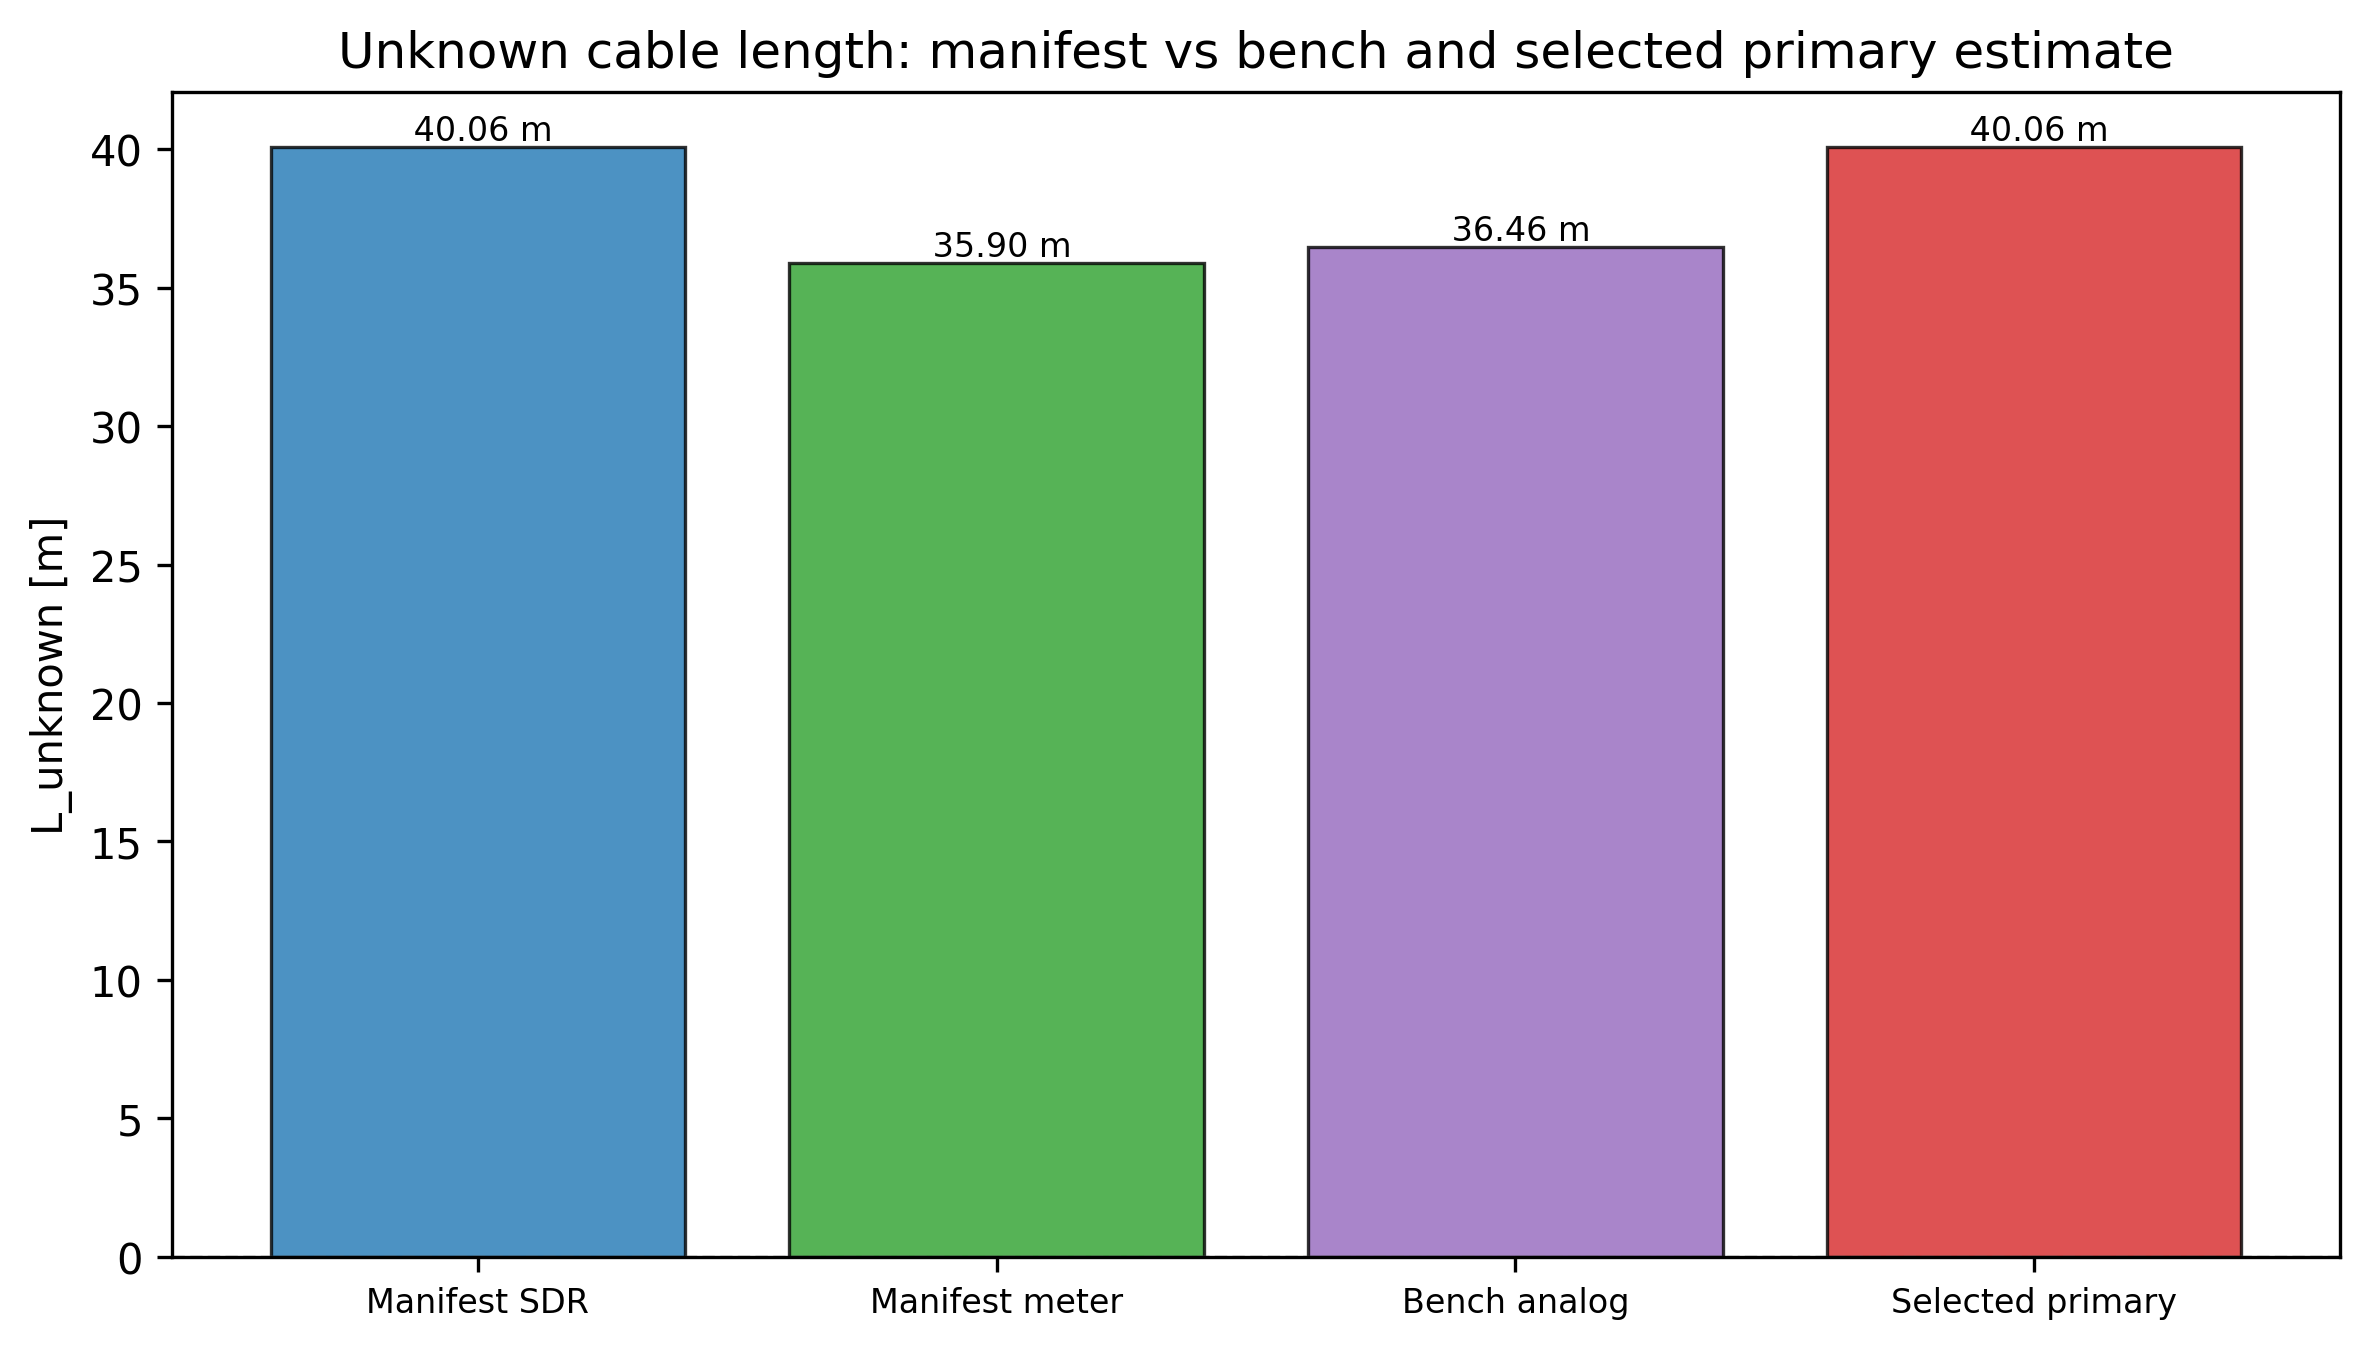

=== Unknown-length cross-check ===
  Manifest SDR   : L_unknown = 40.0589 m
  Manifest meter : L_unknown = 35.9035 m
  SDR - meter    : dL = +4.1555 m (+10.37 % of SDR estimate)
  Bench analog   : L_unknown = 36.4550 m
  Bench - meter  : +0.5516 m
  Bench - SDR    : -3.6039 m

Selected primary source: manifest_sdr_linear
  L_unknown_primary = 40.0589 +/- 5.1702 m


In [18]:
# Unknown-length cross-check between manifest and bench-derived estimates

labels = ['Manifest SDR', 'Manifest meter']
vals = [L_unknown_lin, L_meter_unknown]
colors = ['C0', 'C2']

if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    labels.append('Bench analog')
    vals.append(float(L_unknown_bench_meter_m))
    colors.append('C4')

labels.append('Selected primary')
vals.append(float(L_unknown_primary))
colors.append('C3')

vals_arr = np.asarray(vals, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(np.arange(len(vals_arr)), vals_arr, color=colors, alpha=0.8, edgecolor='k', lw=0.8)
ax.set_xticks(np.arange(len(vals_arr)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('L_unknown [m]')
ax.set_title('Unknown cable length: manifest vs bench and selected primary estimate')
ax.axhline(0, color='gray', lw=0.8, ls='--')
for i, v in enumerate(vals_arr):
    ax.text(i, v, f' {v:.2f} m', va='bottom', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

delta_unknown = L_unknown_lin - L_meter_unknown
frac_delta = 100.0 * delta_unknown / L_unknown_lin if np.isfinite(L_unknown_lin) and L_unknown_lin != 0 else np.nan

print('=== Unknown-length cross-check ===')
print(f'  Manifest SDR   : L_unknown = {L_unknown_lin:.4f} m')
print(f'  Manifest meter : L_unknown = {L_meter_unknown:.4f} m')
print(f'  SDR - meter    : dL = {delta_unknown:+.4f} m ({frac_delta:+.2f} % of SDR estimate)')
if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    print(f'  Bench analog   : L_unknown = {L_unknown_bench_meter_m:.4f} m')
    print(f'  Bench - meter  : {L_unknown_bench_meter_m - L_meter_unknown:+.4f} m')
    print(f'  Bench - SDR    : {L_unknown_bench_meter_m - L_unknown_lin:+.4f} m')

print(f'\nSelected primary source: {primary_length_source}')
print(f'  L_unknown_primary = {L_unknown_primary:.4f} +/- {L_unknown_primary_sigma:.4f} m')


## Cell 10 - Summary tables

This section reports:

- all-point vs screened fit diagnostics,
- SDR and meter attenuation products,
- unknown-length estimates with uncertainty,
- selected primary estimate and justification.

Interpretation notes:

- `alpha [dB/m]` controls length sensitivity strongly,
- `L_unknown [m]` excludes the fixed 12-ft lead-in,
- bench values are consistency checks, not replacement for manifest inference.



## Comparison to RG-58 expectations at 1420 MHz

| Cable / Datasheet | Attenuation at ~1.4 GHz | Equivalent dB/m | Source |
| --- | --- | --- | --- |
| Belden 8240 (RG-58) | 14.5 dB / 100 ft @ 1 GHz | ~0.476 dB/m | Belden datasheet (scaled to 1420 MHz via √f skin-loss assumption) |
| Belden 8259 (RG-58, weather-resistant) | 22.8 dB / 100 ft @ 1 GHz | ~0.748 dB/m | Belden network data |
| Pasternack PE-C195 (RG-58-type) | 13.4 typ / 14.5 max dB / 100 ft @ 1.5 GHz | ~0.440 / 0.476 dB/m | Pasternack spec sheet |

The physical losses of a coaxial line are dominated by conductor resistance (∝√f because the skin depth shrinks as frequency rises) and by dielectric absorption (roughly ∝f for low-loss PTFE), with connectors and adapters adding smaller, often frequency-agnostic penalties. The measured primary slopes lie at 0.728 dB/m (SDR) and 0.804 dB/m (meter) and fall squarely within the RG-58 family range above, while the all-point fits that include the screened long run yield α≈1.85–1.92 dB/m—well above any reasonable RG-58 expectation, highlighting why the long point was excluded. The remaining slopes are thus consistent with a modest mixture of skin effect, dielectric loss, and small connector/adapter mismatches without invoking unfamiliar physics or hidden attenuation mechanisms.



### Additional consistency checks

- Screening the one high-leverage run brings the shared `α` down by ~1.12 dB/m and shifts the inferred `L_unknown` toward the meter-derived ~35.9 m, showing the diagnostics preserve the predictable length response.
- Manifest-meter and bench-analog unknown-length estimates now agree at ~35.9 m vs ~36.5 m, supporting the calibration chain closure and the assumption that both SDR and analog chains share the same cable loss.
- The bench compression/safety checks (safe siggen ≤ 10.95 dBm) remain the best justification for conservative drive levels when exercising the cascaded ZKL amps, preventing the very compression that could otherwise distort the inferred attenuation slopes.


In [19]:
# Analytic CI for manifest SDR linear L_unknown
L_ci68_lo = L_unknown_lin - sigma_L_lin_analytic
L_ci68_hi = L_unknown_lin + sigma_L_lin_analytic
L_ci68_str = f'[{L_ci68_lo:.2f}, {L_ci68_hi:.2f}]'

fit_quality = pd.DataFrame([
    {
        'Fit': 'SDR all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': f"{fit_lin_all['alpha']:.4f} +/- {fit_lin_all['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_lin_all['rmse']:.4f}",
        'AIC': f"{fit_lin_all['aic']:.2f}",
        'BIC': f"{fit_lin_all['bic']:.2f}",
    },
    {
        'Fit': 'SDR primary',
        'n_rows': len(L),
        'alpha [dB/m]': f"{fit_lin['alpha']:.4f} +/- {fit_lin['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_lin['rmse']:.4f}",
        'AIC': f"{fit_lin['aic']:.2f}",
        'BIC': f"{fit_lin['bic']:.2f}",
    },
    {
        'Fit': 'Meter all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': f"{fit_meter_all['alpha']:.4f} +/- {fit_meter_all['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_meter_all['rmse']:.4f}",
        'AIC': f"{fit_meter_all['aic']:.2f}",
        'BIC': f"{fit_meter_all['bic']:.2f}",
    },
    {
        'Fit': 'Meter primary',
        'n_rows': len(L),
        'alpha [dB/m]': f"{fit_meter['alpha']:.4f} +/- {fit_meter['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_meter['rmse']:.4f}",
        'AIC': f"{fit_meter['aic']:.2f}",
        'BIC': f"{fit_meter['bic']:.2f}",
    },
]).set_index('Fit')

estimate_summary = pd.DataFrame([
    {
        'Estimate': 'Manifest SDR',
        'L_unknown [m]': f'{L_unknown_lin:.3f}',
        'Uncertainty': L_ci68_str,
        'Notes': 'analytic +/-1sigma (linear propagation)',
    },
    {
        'Estimate': 'Manifest meter',
        'L_unknown [m]': f'{L_meter_unknown:.3f}',
        'Uncertainty': f'+/- {sigma_L_meter_unknown:.3f} m',
        'Notes': 'analytic propagation (model params)',
    },
    {
        'Estimate': 'Selected primary',
        'L_unknown [m]': f'{L_unknown_primary:.3f}',
        'Uncertainty': f'+/- {L_unknown_primary_sigma:.3f} m',
        'Notes': primary_length_source,
    },
]).set_index('Estimate')

if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    bench_unc = 'N/A'
    if 'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m):
        bench_unc = f'+/- {L_unknown_bench_meter_sigma_m:.3f} m (alpha only)'
    estimate_summary.loc['Bench analog'] = {
        'L_unknown [m]': f'{L_unknown_bench_meter_m:.3f}',
        'Uncertainty': bench_unc,
        'Notes': 'consistency cross-check',
    }

print('Fit-quality summary:')
display(fit_quality)

print('\nUnknown-length estimate summary:')
display(estimate_summary)

if 'df_bench_metrics' in globals():
    print('\nBench chain-derived metrics (Cell 7c):')
    display(df_bench_metrics)

if 'safe_siggen_dbm_est' in globals() and np.isfinite(safe_siggen_dbm_est):
    print('\nBench safety recommendation:')
    print(f'  Conservative recommended siggen setpoint for cascaded ZKL tests: <= {safe_siggen_dbm_est:.2f} dBm')

print(f'\nFixed lead-in length: {UNKNOWN_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')
print(f'Primary unknown-length source: {primary_length_source}')

Fit-quality summary:


,n_rows,alpha [dB/m],RMSE [dB],AIC,BIC
Fit,,,,,
SDR all-point,9,1.8532 +/- 0.2607,2.5415,39.58,42.25
SDR primary,8,0.7281 +/- 0.1269,0.7953,-1.33,0.99
Meter all-point,9,1.9153 +/- 0.3608,2.4021,19.77,20.17
Meter primary,8,0.8037 +/- 0.0292,0.1242,-29.38,-29.22



Unknown-length estimate summary:


,L_unknown [m],Uncertainty,Notes
Estimate,,,
Manifest SDR,40.059,"[34.89, 45.23]",analytic +/-1sigma (linear propagation)
Manifest meter,35.903,+/- 1.370 m,analytic propagation (model params)
Selected primary,40.059,+/- 5.170 m,manifest_sdr_linear
Bench analog,36.455,N/A,consistency cross-check



Bench chain-derived metrics (Cell 7c):


,metric,value,uncertainty_db,unit
0,baseline_loss_db,4.3,0.141421,dB
1,unknown_incremental_loss_db,29.3,0.141421,dB
2,roof_chain_net_gain_db,31.5,0.141421,dB
3,kl_filter_incremental_loss_db,20.3,0.141421,dB
4,wide_narrow_net_gain_db,12.1,0.141421,dB
5,lab_net_vs_baseline_db,-8.2,0.141421,dB



Bench safety recommendation:
  Conservative recommended siggen setpoint for cascaded ZKL tests: <= 10.95 dBm

Fixed lead-in length: 3.6576 m (12.0 ft)
Primary unknown-length source: manifest_sdr_linear


## Cell 10b - SDR gain sweep analysis (fixed SDR gain)

This section analyzes `data/lab02/sdr_gain_sweep/manifest.csv` to identify the
usable linear-response range of the SDR chain at fixed requested gain
(`sdr_gain_db = 0` in this run).

Outputs:

- response curve: `total_power_db` vs signal-generator setpoint,
- clipping diagnostics from I/Q sample saturation fractions,
- meter consistency trend (`manual_meter_dbm - siggen_amp_dbm`),
- per-LO fit-quality summary on unclipped points.

Interpretation policy in this notebook:

- `clip_max_frac = max(i_clip_frac, q_clip_frac)`,
- points with `clip_max_frac >= 1e-3` are marked clipped and excluded from the
  linear-fit diagnostics.

Sweep manifest rows: 16
LO groups          : [1420.0]
Clip threshold     : 1.0e-03


,point_id,lo_mhz,sdr_gain_db,siggen_amp_dbm,manual_meter_dbm,total_power_db,i_clip_frac,q_clip_frac,clip_max_frac,is_clipped
15,16,1420.0,0.0,-19.5,-23.2,8.639950,0.000000,0.00000,0.00000,False
14,15,1420.0,0.0,-17.0,-20.5,11.106330,0.000000,0.00000,0.00000,False
13,14,1420.0,0.0,-14.5,-17.8,13.582777,0.000000,0.00000,0.00000,False
12,13,1420.0,0.0,-12.0,-15.3,16.005255,0.000000,0.00000,0.00000,False
11,12,1420.0,0.0,-9.5,-12.9,18.354068,0.000000,0.00000,0.00000,False
10,11,1420.0,0.0,-7.0,-10.4,20.931700,0.000000,0.00000,0.00000,False
9,10,1420.0,0.0,-4.5,-7.9,23.321944,0.000000,0.00000,0.00000,False
8,9,1420.0,0.0,-2.0,-5.4,25.880617,0.000000,0.00000,0.00000,False
7,8,1420.0,0.0,0.5,-2.9,28.410106,0.000000,0.00000,0.00000,False
6,7,1420.0,0.0,3.0,-0.3,31.081844,0.000000,0.00000,0.00000,False


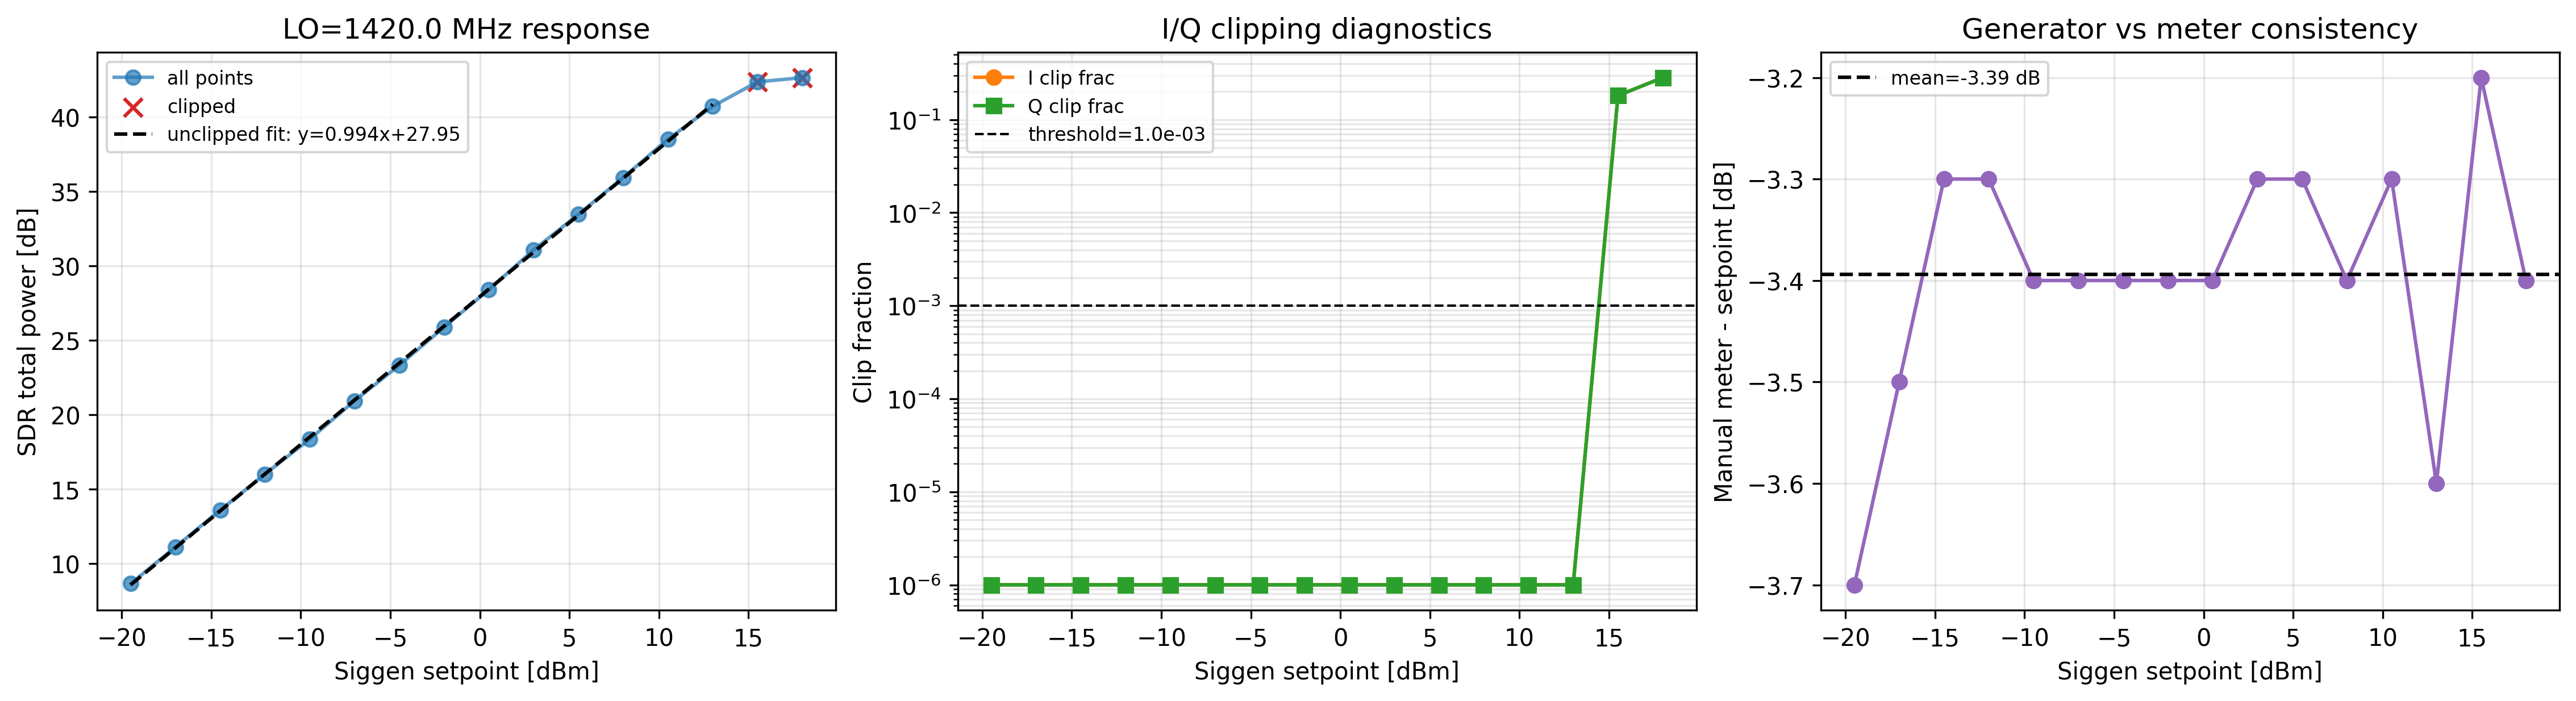

Per-LO fixed-gain sweep diagnostics (unclipped-fit based):


,lo_mhz,n_points,n_unclipped,n_clipped,highest_unclipped_setpoint_dbm,first_clipped_setpoint_dbm,slope_total_power_db_per_dbm,rmse_db,r2,meter_minus_set_mean_db,meter_minus_set_std_db
0,1420.0,16,14,2,13.0,15.5,0.994312,0.097879,0.999905,-3.39375,0.119733


Manifest-derived diagnostics above are the canonical SDR gain-sweep outputs.


In [20]:
# Load and analyze fixed-gain SDR sweep data.
SWEEP_MANIFEST = DATA_ROOT / 'sdr_gain_sweep' / 'manifest.csv'
CLIP_THRESH = 1e-3
EPS = 1e-6

if not SWEEP_MANIFEST.exists():
    raise FileNotFoundError(f'Missing sweep manifest: {SWEEP_MANIFEST}')

df_sweep = pd.read_csv(SWEEP_MANIFEST).copy()
required_cols = [
    'lo_mhz', 'siggen_amp_dbm', 'total_power_db',
    'i_clip_frac', 'q_clip_frac', 'manual_meter_dbm',
]
missing = [c for c in required_cols if c not in df_sweep.columns]
if missing:
    raise KeyError(f'Sweep manifest missing required columns: {missing}')

df_sweep['clip_max_frac'] = df_sweep[['i_clip_frac', 'q_clip_frac']].max(axis=1)
df_sweep['meter_minus_set_db'] = df_sweep['manual_meter_dbm'] - df_sweep['siggen_amp_dbm']
df_sweep['is_clipped'] = df_sweep['clip_max_frac'] >= CLIP_THRESH

print(f'Sweep manifest rows: {len(df_sweep)}')
print(f'LO groups          : {sorted(df_sweep["lo_mhz"].dropna().unique().tolist())}')
print(f'Clip threshold     : {CLIP_THRESH:.1e}')

display(
    df_sweep.sort_values(['lo_mhz', 'siggen_amp_dbm'])[
        ['point_id', 'lo_mhz', 'sdr_gain_db', 'siggen_amp_dbm', 'manual_meter_dbm',
         'total_power_db', 'i_clip_frac', 'q_clip_frac', 'clip_max_frac', 'is_clipped']
    ]
)

fit_rows = []
for lo_mhz, grp in df_sweep.groupby('lo_mhz', sort=True):
    g = grp.sort_values('siggen_amp_dbm').reset_index(drop=True)
    unclipped = g[g['is_clipped'] == False]
    clipped = g[g['is_clipped']]

    slope = np.nan
    intercept = np.nan
    rmse = np.nan
    r2 = np.nan
    if len(unclipped) >= 2:
        x = unclipped['siggen_amp_dbm'].to_numpy(dtype=float)
        y = unclipped['total_power_db'].to_numpy(dtype=float)
        slope, intercept = np.polyfit(x, y, 1)
        yhat = slope * x + intercept
        resid = y - yhat
        rmse = float(np.sqrt(np.mean(resid**2)))
        ss_res = float(np.sum(resid**2))
        ss_tot = float(np.sum((y - np.mean(y))**2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    first_clipped = float(np.min(clipped['siggen_amp_dbm'])) if len(clipped) else np.nan
    highest_unclipped = float(np.max(unclipped['siggen_amp_dbm'])) if len(unclipped) else np.nan

    fit_rows.append({
        'lo_mhz': float(lo_mhz),
        'n_points': int(len(g)),
        'n_unclipped': int(len(unclipped)),
        'n_clipped': int(len(clipped)),
        'highest_unclipped_setpoint_dbm': highest_unclipped,
        'first_clipped_setpoint_dbm': first_clipped,
        'slope_total_power_db_per_dbm': slope,
        'rmse_db': rmse,
        'r2': r2,
        'meter_minus_set_mean_db': float(np.nanmean(g['meter_minus_set_db'])),
        'meter_minus_set_std_db': float(np.nanstd(g['meter_minus_set_db'])),
    })

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    axes[0].plot(g['siggen_amp_dbm'], g['total_power_db'], 'o-', color='C0', alpha=0.7, label='all points')
    if len(clipped):
        axes[0].scatter(clipped['siggen_amp_dbm'], clipped['total_power_db'],
                        marker='x', s=60, color='C3', label='clipped')
    if len(unclipped) >= 2:
        xfit = np.linspace(unclipped['siggen_amp_dbm'].min(), unclipped['siggen_amp_dbm'].max(), 200)
        axes[0].plot(xfit, slope * xfit + intercept, '--', color='k',
                     label=f'unclipped fit: y={slope:.3f}x+{intercept:.2f}')
    axes[0].set_xlabel('Siggen setpoint [dBm]')
    axes[0].set_ylabel('SDR total power [dB]')
    axes[0].set_title(f'LO={lo_mhz:.1f} MHz response')
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].plot(g['siggen_amp_dbm'], np.clip(g['i_clip_frac'], EPS, None), 'o-', label='I clip frac', color='C1')
    axes[1].plot(g['siggen_amp_dbm'], np.clip(g['q_clip_frac'], EPS, None), 's-', label='Q clip frac', color='C2')
    axes[1].axhline(CLIP_THRESH, color='k', ls='--', lw=1.0, label=f'threshold={CLIP_THRESH:.1e}')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Siggen setpoint [dBm]')
    axes[1].set_ylabel('Clip fraction')
    axes[1].set_title('I/Q clipping diagnostics')
    axes[1].grid(alpha=0.3, which='both')
    axes[1].legend(fontsize=8)

    axes[2].plot(g['siggen_amp_dbm'], g['meter_minus_set_db'], 'o-', color='C4')
    axes[2].axhline(np.nanmean(g['meter_minus_set_db']), color='k', ls='--',
                    label=f'mean={np.nanmean(g["meter_minus_set_db"]):.2f} dB')
    axes[2].set_xlabel('Siggen setpoint [dBm]')
    axes[2].set_ylabel('Manual meter - setpoint [dB]')
    axes[2].set_title('Generator vs meter consistency')
    axes[2].grid(alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.show()

fit_df = pd.DataFrame(fit_rows).sort_values('lo_mhz').reset_index(drop=True)
print('Per-LO fixed-gain sweep diagnostics (unclipped-fit based):')
display(fit_df)

print('Manifest-derived diagnostics above are the canonical SDR gain-sweep outputs.')


## Future uses of calibration products

Use this section as the downstream contract for reusing outputs from this notebook.

### 1) Recommended products to carry forward

- SDR attenuation fit: `alpha`, `B1420`, `B1421`, and uncertainties.
- Meter attenuation fit: `alpha_meter`, `B_meter`, and uncertainty.
- Unknown-cable estimates: SDR, meter, and selected primary estimate.
- Analytic uncertainty intervals for SDR-based unknown length.

### 2) Required conventions for consistent reuse

- Keep the same normalisation:
  $y = 10\log_{10}(P_{\mathrm{total}})-P_{\mathrm{siggen,dBm}}$.
- Preserve fixed lead-in subtraction:
  $L_{\mathrm{unknown}}=L_{\mathrm{total}}-3.6576\,\mathrm{m}$.
- Preserve diagnostics-first screening policy (no blind hard-coded point dropping).

### 3) Cross-referenced workflows (out-of-scope here)

- The termination and square-wave reflectometry derivation is now embedded in this notebook (see the dedicated section above); `labs/02/termination_reflectometry.ipynb` remains as an archival reference.
- Full Y-factor intensity calibration and temperature-scale export:
  `labs/02/temperature_calibration.ipynb`.
- Spectral-line profile fitting and LSR velocity analysis:
  `labs/02/analysis.ipynb`.

## Cell 11 — RTL2832U FIR Filter Bandpass Characterisation (Goal 4 / E)

The RTL2832U applies a 32-tap anti-aliasing FIR before decimation.
Default coefficients from `bighorn.tex`:

$$
h = [-54,-36,-41,-40,-32,-14,14,53,101,156,215,273,327,372,404,421,
     421,404,372,327,273,215,156,101,53,14,-14,-32,-40,-41,-36,-54].
$$

Estimated secondary summing filter from `bighorn.tex`:

$$
g = [-1/8,-1/4,-3/4,-1/2,-1,8,-1,-1/2,-3/4,-1/4,-1/8].
$$

In this revision:

- FFT channel count is taken from the loaded **cold_ref** spectrum,
- response and passband masks are built on that exact channel grid,
- passband diagnostics avoid near-zero stopband divisions.


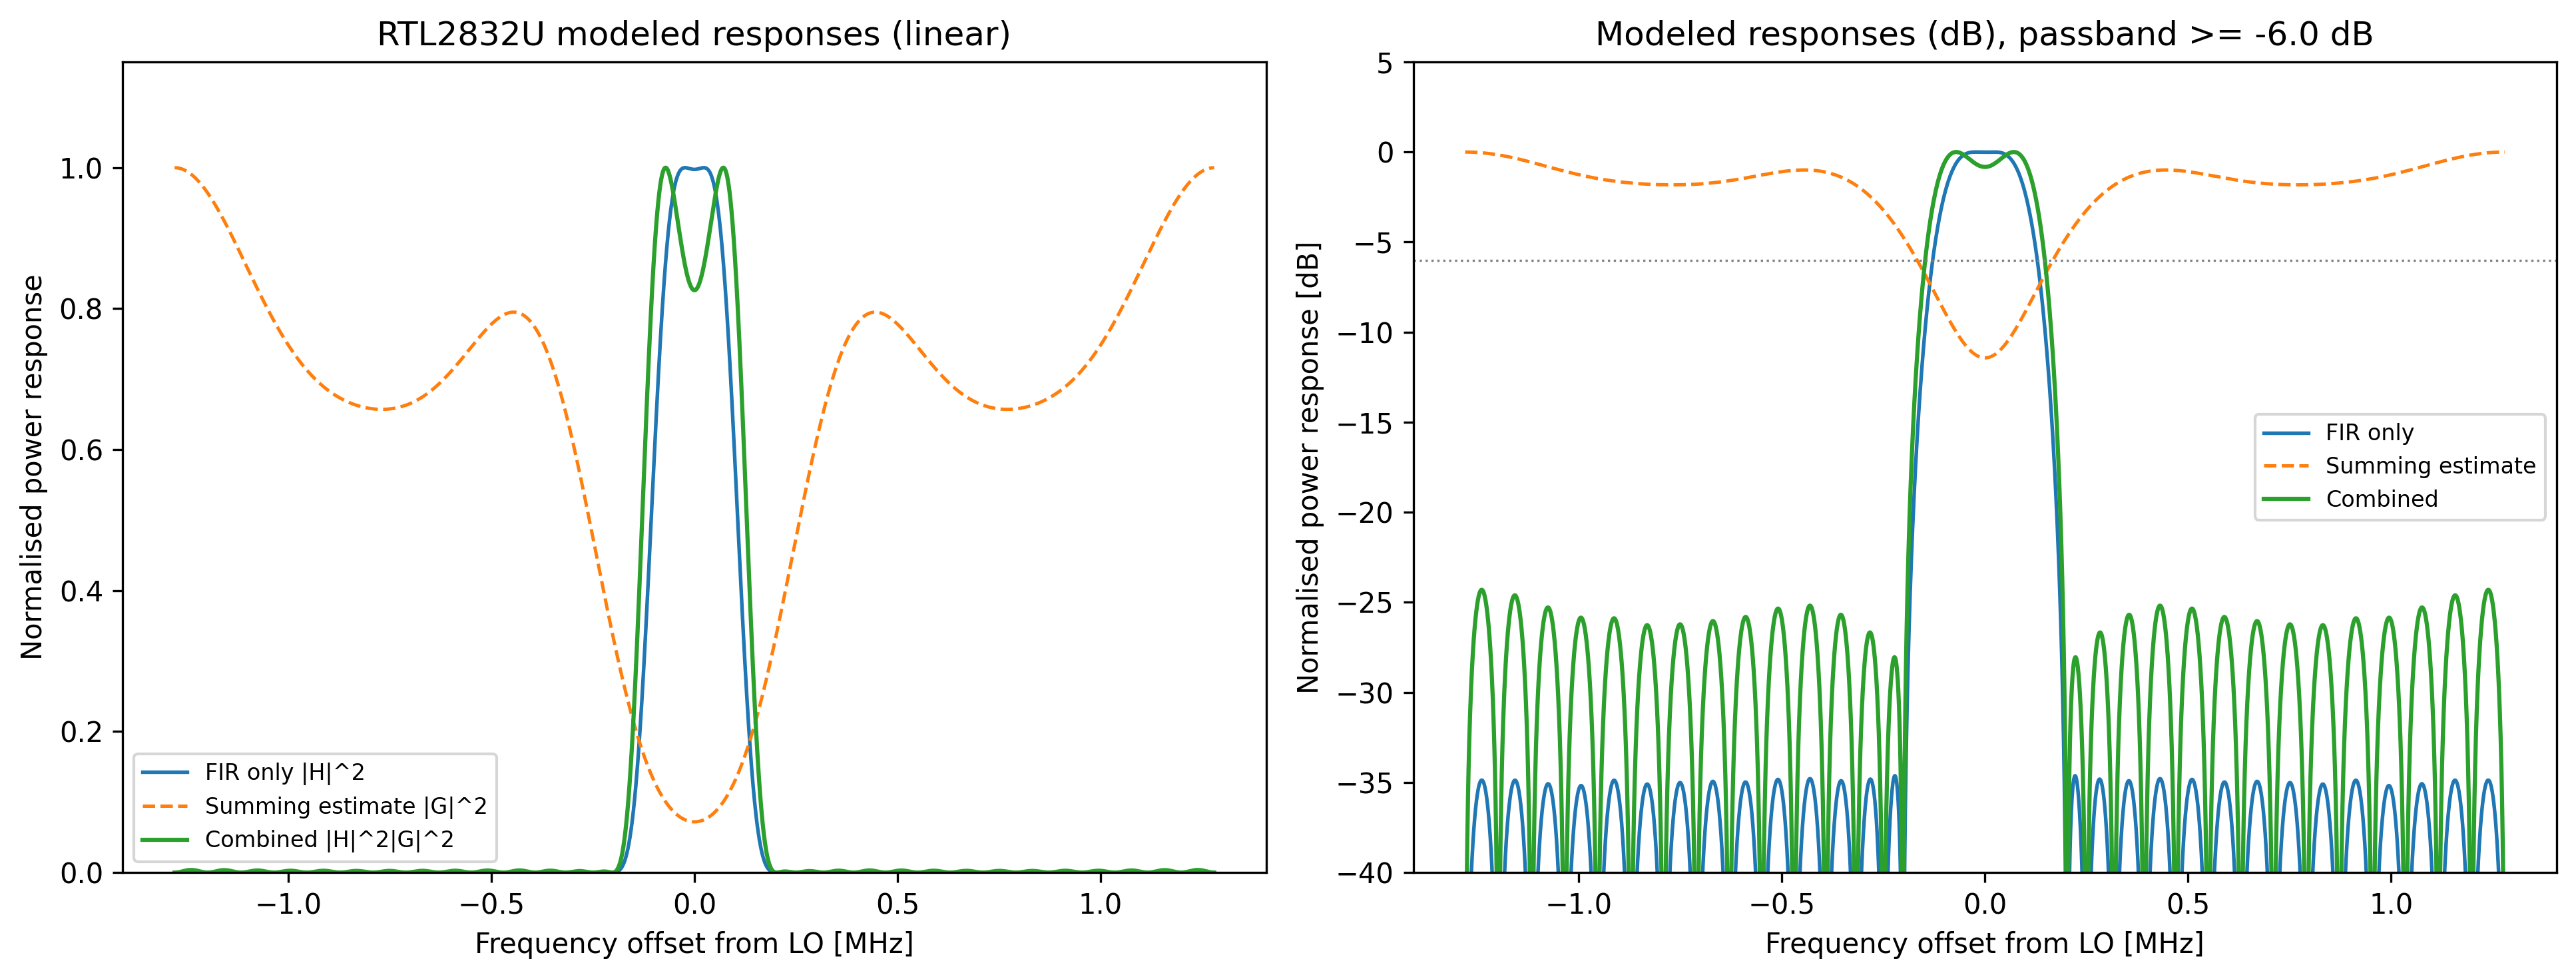

cold_ref reference path : ../../data/lab02/cold_ref_combined_spectra/GAL-1420_combined.npz
N_FFT (data-driven)     : 8192
sample rate             : 2.560 MHz
passband channels       : 825 / 8192 (10.07%) at threshold -6.0 dB
FIR passband ripple (5-95 pct): 4.995 dB
FIR+summing(est) ripple (5-95 pct): 2.263 dB


In [21]:
# ── RTL2832U FIR coefficients (bighorn.tex default, 32-tap symmetric) ────────
h_fir = np.array([
    -54, -36, -41, -40, -32, -14,  14,  53,
    101, 156, 215, 273, 327, 372, 404, 421,
    421, 404, 372, 327, 273, 215, 156, 101,
     53,  14, -14, -32, -40, -41, -36, -54,
], dtype=float)

# Secondary summing filter estimate (bighorn.tex)
g_sum_est = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8, -1, -1/2, -3/4, -1/4, -1/8], dtype=float)

# ── Resolve cold_ref reference spectrum (requested: use cold_ref, not SGP) ───
COLD_REF_PATH = DATA_ROOT / 'cold_ref_combined_spectra' / 'GAL-1420_combined.npz'
if not COLD_REF_PATH.exists():
    raise FileNotFoundError(
        f'Missing cold_ref combined spectrum: {COLD_REF_PATH}. '
        'Run combination pipeline or update path policy.'
    )

spec_noise = Spectrum.load(COLD_REF_PATH)
N_FFT = int(np.asarray(spec_noise.psd).size)
SAMPLE_RATE_HZ = float(spec_noise.sample_rate)

# Use shifted (low->high) ordering to match Spectrum.freqs ordering
freq_offset_mhz = (np.asarray(spec_noise.freqs, float) - float(spec_noise.center_freq)) / 1e6

# DFT responses, then shift to low->high order
P_fir = np.abs(np.fft.fft(h_fir, n=N_FFT))**2
P_sum_est = np.abs(np.fft.fft(g_sum_est, n=N_FFT))**2
P_combined_est = P_fir * P_sum_est

P_fir_norm_shifted = np.fft.fftshift(P_fir / np.max(P_fir))
P_sum_est_norm_shifted = np.fft.fftshift(P_sum_est / np.max(P_sum_est))
P_combined_est_norm_shifted = np.fft.fftshift(P_combined_est / np.max(P_combined_est))

# Response-defined passband mask (avoid near-zero denominator bins)
PASSBAND_DB_THRESHOLD = -6.0
passband_floor = 10 ** (PASSBAND_DB_THRESHOLD / 10.0)
passband_mask = P_fir_norm_shifted >= passband_floor

if np.sum(passband_mask) < max(64, N_FFT // 200):
    PASSBAND_DB_THRESHOLD = -10.0
    passband_floor = 10 ** (PASSBAND_DB_THRESHOLD / 10.0)
    passband_mask = P_fir_norm_shifted >= passband_floor


def _pct_ripple_db(x: np.ndarray, mask: np.ndarray, lo: float = 5.0, hi: float = 95.0) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    qlo, qhi = np.percentile(v, [lo, hi])
    return float(10.0 * np.log10(qhi / qlo))


# Plot modeled responses
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(freq_offset_mhz, P_fir_norm_shifted, lw=1.3, label='FIR only |H|^2', color='C0')
ax.plot(freq_offset_mhz, P_sum_est_norm_shifted, lw=1.2, ls='--', label='Summing estimate |G|^2', color='C1')
ax.plot(freq_offset_mhz, P_combined_est_norm_shifted, lw=1.5, label='Combined |H|^2|G|^2', color='C2')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power response')
ax.set_title('RTL2832U modeled responses (linear)')
ax.legend(fontsize=8)
ax.set_ylim(0.0, 1.15)

ax = axes[1]
with np.errstate(divide='ignore'):
    ax.plot(freq_offset_mhz, 10*np.log10(np.clip(P_fir_norm_shifted, 1e-12, None)), lw=1.3, color='C0', label='FIR only')
    ax.plot(freq_offset_mhz, 10*np.log10(np.clip(P_sum_est_norm_shifted, 1e-12, None)), lw=1.2, ls='--', color='C1', label='Summing estimate')
    ax.plot(freq_offset_mhz, 10*np.log10(np.clip(P_combined_est_norm_shifted, 1e-12, None)), lw=1.5, color='C2', label='Combined')
ax.axhline(PASSBAND_DB_THRESHOLD, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power response [dB]')
ax.set_title(f'Modeled responses (dB), passband >= {PASSBAND_DB_THRESHOLD:.1f} dB')
ax.legend(fontsize=8)
ax.set_ylim(-40, 5)

fig.tight_layout()
plt.show()

print(f'cold_ref reference path : {COLD_REF_PATH}')
print(f'N_FFT (data-driven)     : {N_FFT}')
print(f'sample rate             : {SAMPLE_RATE_HZ/1e6:.3f} MHz')
print(f'passband channels       : {int(np.sum(passband_mask))} / {N_FFT} '
      f'({100*np.mean(passband_mask):.2f}%) at threshold {PASSBAND_DB_THRESHOLD:.1f} dB')
print(f'FIR passband ripple (5-95 pct): {_pct_ripple_db(P_fir_norm_shifted, passband_mask):.3f} dB')
print(f'FIR+summing(est) ripple (5-95 pct): {_pct_ripple_db(P_combined_est_norm_shifted, passband_mask):.3f} dB')


## Cell 12 — White-Noise Verification with `cold_ref`

### Broadband proxy choice

Per request, this notebook uses the **cold_ref** combined spectrum (not SGP) as the broadband reference for bandpass verification.

The check is empirical:

1. take the measured cold-reference PSD,
2. mask narrow-band outliers (RFI-like spikes),
3. divide by modeled responses,
4. assess residual passband flatness inside a response-defined passband mask.

### Why response-defined passband mask matters

Directly evaluating ripple over channels where model response approaches zero produces artificial blow-ups. This revision computes ripple only in channels where modeled FIR response is above the selected dB threshold.


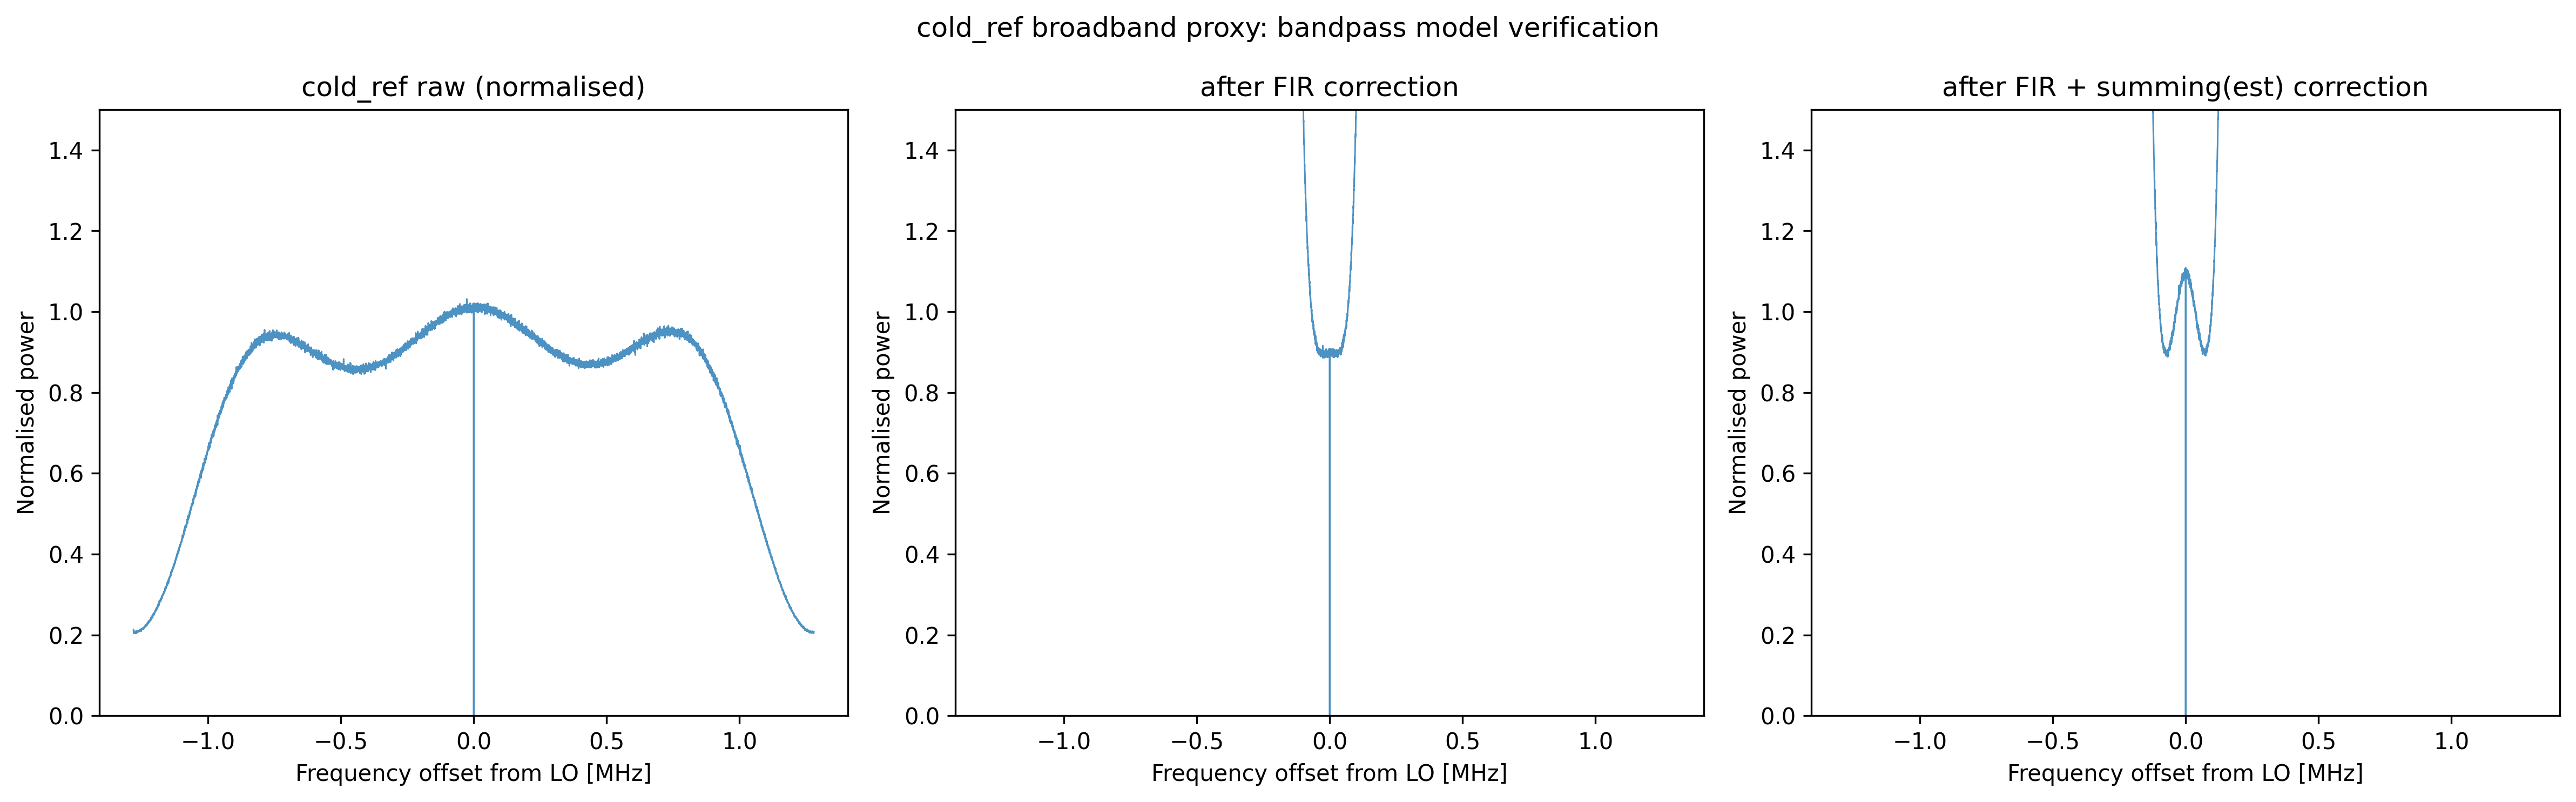

RFI mask kept channels            : 8064 / 8192 (98.44%)
Combined eval mask channels       : 778 / 8192 (9.50%)
Ripple raw (5-95 pct, eval mask)  : 0.143 dB
Ripple after FIR                   : 4.957 dB
Ripple after FIR+sum(est)          : 2.214 dB
Frac std raw / FIR / FIR+sum(est) : 0.0100 / 0.6135 / 0.1811


In [22]:
# ── Cold-ref white-noise proxy verification ───────────────────────────────────
noise_psd_shifted = np.asarray(spec_noise.psd, float)  # low->high ordering

# Robust Savitzky-Golay baseline for narrow-band outlier mask
from scipy.signal import savgol_filter

window = min(257, N_FFT - (1 - N_FFT % 2))
if window < 7:
    window = 7 if N_FFT >= 7 else (N_FFT // 2) * 2 + 1

baseline = savgol_filter(noise_psd_shifted, window_length=window, polyorder=3, mode='interp')
resid = noise_psd_shifted - baseline
med_resid = float(np.median(resid))
mad = float(np.median(np.abs(resid - med_resid)))
scale = 1.4826 * mad if mad > 0 else float(np.std(resid))

if scale <= 0:
    rfi_mask = np.ones_like(noise_psd_shifted, dtype=bool)
else:
    rfi_mask = np.abs(resid - med_resid) < 3.0 * scale

combined_mask = passband_mask & rfi_mask
if np.sum(combined_mask) < 64:
    combined_mask = passband_mask.copy()

response_floor = 10 ** (-20.0 / 10.0)


def _normalise_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return np.asarray(x, float)
    med = float(np.median(v))
    return np.asarray(x, float) / med


def _ripple_db(x: np.ndarray, mask: np.ndarray, lo: float = 5.0, hi: float = 95.0) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    qlo, qhi = np.percentile(v, [lo, hi])
    return float(10.0 * np.log10(qhi / qlo))


def _frac_std(x: np.ndarray, mask: np.ndarray) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    vn = v / np.median(v)
    return float(np.std(vn - 1.0))


noise_norm = _normalise_in_mask(noise_psd_shifted, combined_mask)
after_fir = noise_norm / np.clip(P_fir_norm_shifted, response_floor, None)
after_both_est = noise_norm / np.clip(P_combined_est_norm_shifted, response_floor, None)

after_fir_n = _normalise_in_mask(after_fir, combined_mask)
after_both_est_n = _normalise_in_mask(after_both_est, combined_mask)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    (noise_norm, 'cold_ref raw (normalised)'),
    (after_fir_n, 'after FIR correction'),
    (after_both_est_n, 'after FIR + summing(est) correction'),
]

for ax, (data, title) in zip(axes, panels):
    ax.plot(freq_offset_mhz, data, lw=0.7, alpha=0.8, color='C0')
    ax.set_xlabel('Frequency offset from LO [MHz]')
    ax.set_ylabel('Normalised power')
    ax.set_title(title)
    ax.set_ylim(0.0, 1.5)

fig.suptitle('cold_ref broadband proxy: bandpass model verification')
fig.tight_layout()
plt.show()

print(f'RFI mask kept channels            : {int(np.sum(rfi_mask))} / {N_FFT} ({100*np.mean(rfi_mask):.2f}%)')
print(f'Combined eval mask channels       : {int(np.sum(combined_mask))} / {N_FFT} ({100*np.mean(combined_mask):.2f}%)')
print(f'Ripple raw (5-95 pct, eval mask)  : {_ripple_db(noise_norm, combined_mask):.3f} dB')
print(f'Ripple after FIR                   : {_ripple_db(after_fir_n, combined_mask):.3f} dB')
print(f'Ripple after FIR+sum(est)          : {_ripple_db(after_both_est_n, combined_mask):.3f} dB')
print(f'Frac std raw / FIR / FIR+sum(est) : '
      f'{_frac_std(noise_norm, combined_mask):.4f} / '
      f'{_frac_std(after_fir_n, combined_mask):.4f} / '
      f'{_frac_std(after_both_est_n, combined_mask):.4f}')


## Cell 13 — Summing-Filter Optimisation (Goal 4 / E)

Residual passband structure after FIR-only correction is used to refine the summing-filter model.

### Constrained parameterisation

Instead of unconstrained 10-tap fitting, this revision fits a **symmetric 11-tap** filter:

$$
g = [a,b,c,d,e,f,e,d,c,b,a],
$$

which enforces linear-phase symmetry and keeps the optimization physically interpretable.

### Objective

Minimize the in-passband variance of the corrected, median-normalized cold_ref spectrum. Lower variance indicates flatter residual bandpass.

Outputs reported:

- initial vs optimized objective,
- initial vs optimized ripple in the evaluation passband,
- optimized symmetric coefficients.


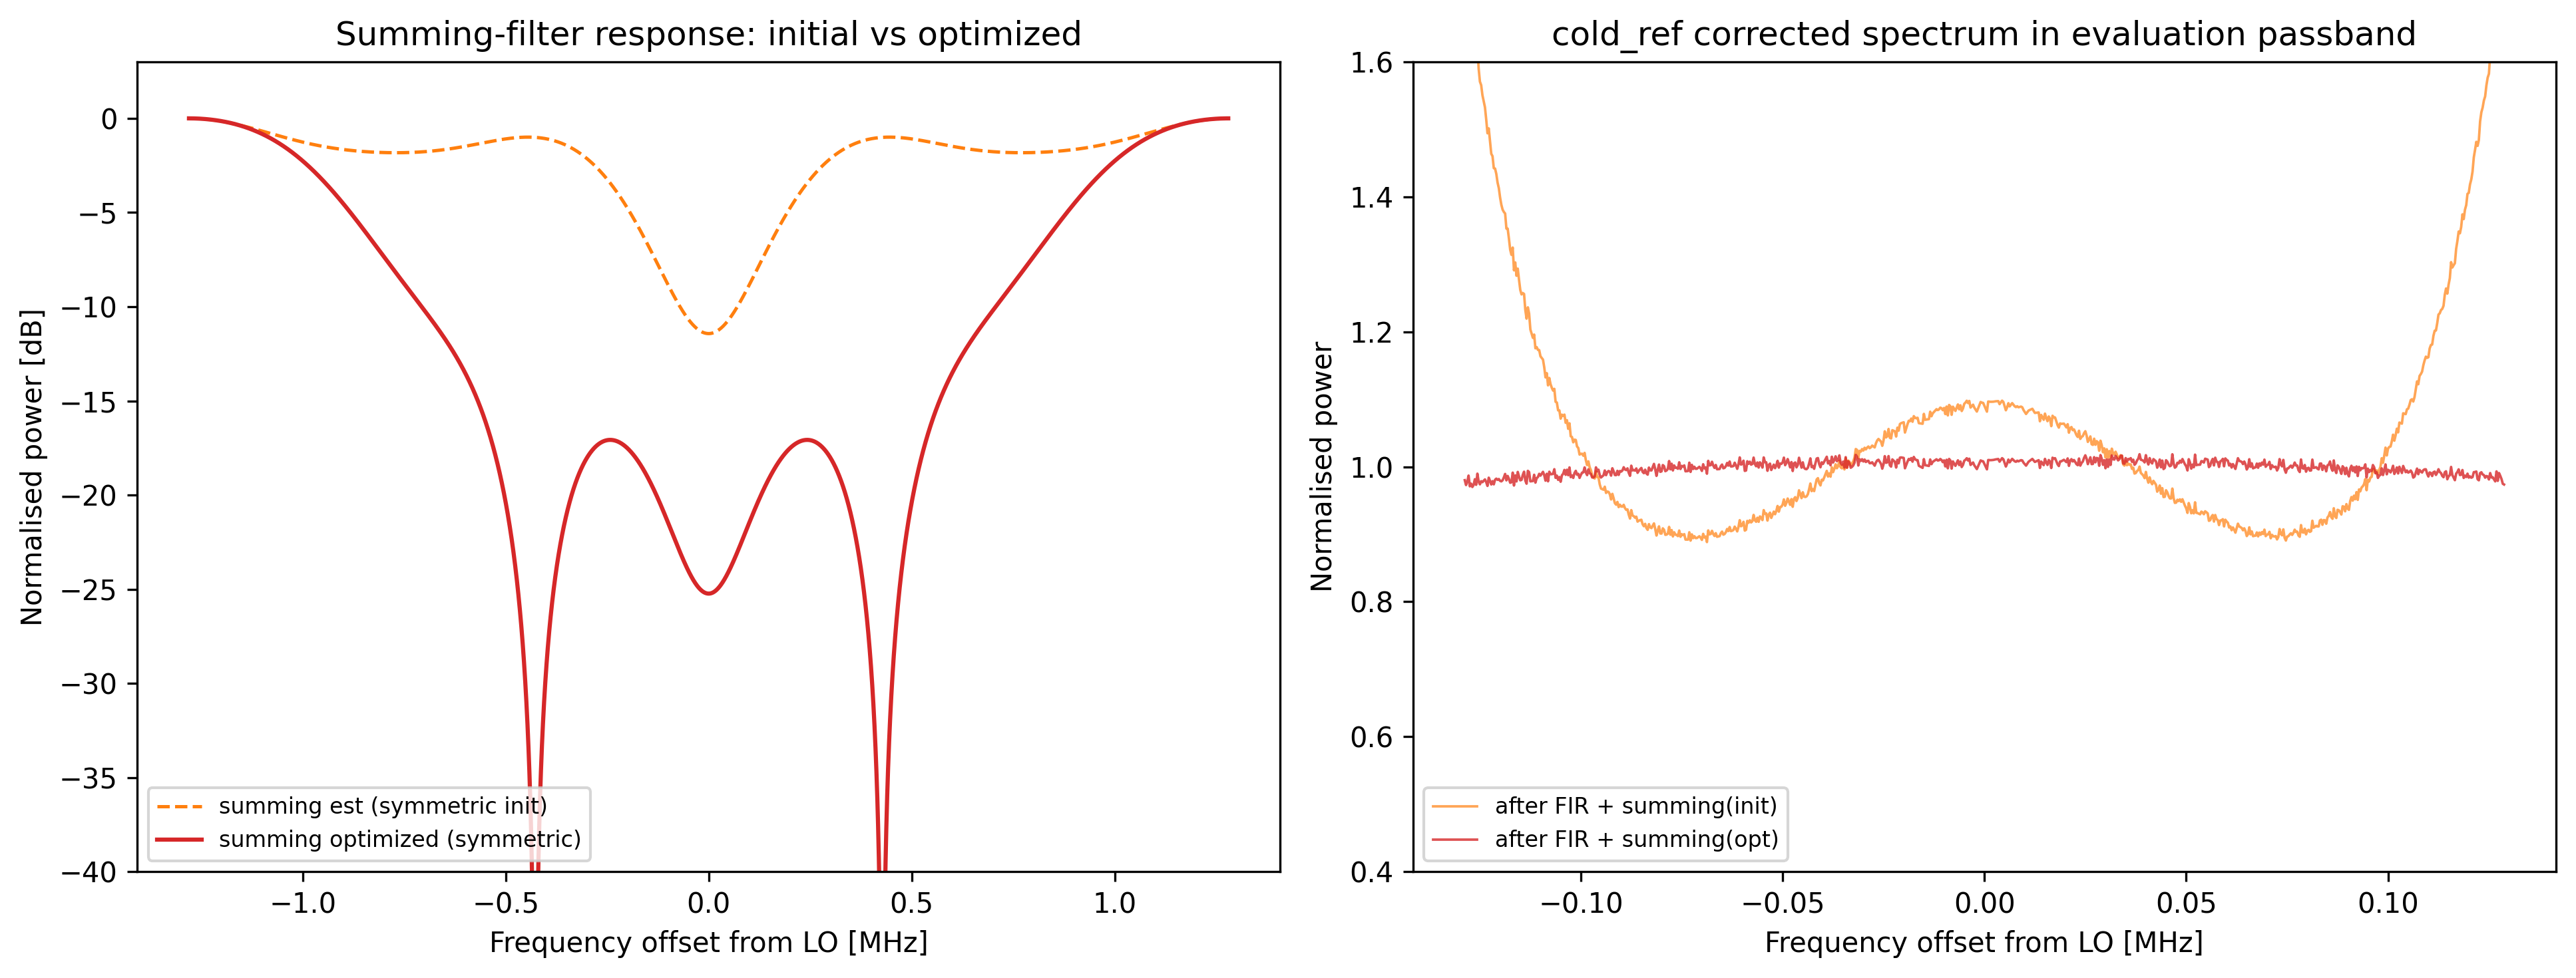

Optimization converged: True  (message: Optimization terminated successfully.)
Initial objective variance : 3.278829e-02
Optimized objective variance: 9.971448e-05
Ripple after init summing  : 2.214 dB
Ripple after opt summing   : 0.143 dB
Ripple improvement         : +2.071 dB

Optimized symmetric 11-tap summing coefficients:
[1.375022, 1.582352, -0.216283, 5.223888, -25.97058, 30.861103, -25.97058, 5.223888, -0.216283, 1.582352, 1.375022]


In [23]:
from scipy.optimize import minimize

# Symmetric 11-tap parameterisation: [a,b,c,d,e,f,e,d,c,b,a]
def make_symmetric_sum_filter(theta6: np.ndarray) -> np.ndarray:
    a, b, c, d, e, f = np.asarray(theta6, float)
    return np.array([a, b, c, d, e, f, e, d, c, b, a], dtype=float)


def summing_response_norm_shifted(g_coeffs: np.ndarray) -> np.ndarray:
    P = np.abs(np.fft.fft(np.asarray(g_coeffs, float), n=N_FFT))**2
    P = P / np.max(P)
    return np.fft.fftshift(P)


def corrected_with_summing(P_sum_norm_shifted: np.ndarray) -> np.ndarray:
    return noise_norm / np.clip(P_fir_norm_shifted * P_sum_norm_shifted, response_floor, None)


def objective(theta6: np.ndarray) -> float:
    g = make_symmetric_sum_filter(theta6)
    P_sum = summing_response_norm_shifted(g)
    corr = corrected_with_summing(P_sum)

    x = np.asarray(corr, float)[combined_mask]
    x = x[np.isfinite(x) & (x > 0)]
    if x.size < 64:
        return 1e10

    x = x / np.median(x)
    return float(np.var(x))


theta_init = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8], dtype=float)
g_init = make_symmetric_sum_filter(theta_init)
P_sum_init_norm_shifted = summing_response_norm_shifted(g_init)

after_init = corrected_with_summing(P_sum_init_norm_shifted)
after_init_n = _normalise_in_mask(after_init, combined_mask)

result = minimize(
    objective,
    theta_init,
    method='Nelder-Mead',
    options={'maxiter': 60_000, 'xatol': 1e-9, 'fatol': 1e-12, 'adaptive': True},
)

theta_opt = np.asarray(result.x, float)
g_opt = make_symmetric_sum_filter(theta_opt)
P_sum_opt_norm_shifted = summing_response_norm_shifted(g_opt)

after_opt = corrected_with_summing(P_sum_opt_norm_shifted)
after_opt_n = _normalise_in_mask(after_opt, combined_mask)

ripple_init = _ripple_db(after_init_n, combined_mask)
ripple_opt = _ripple_db(after_opt_n, combined_mask)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
with np.errstate(divide='ignore'):
    ax.plot(freq_offset_mhz, 10*np.log10(np.clip(P_sum_init_norm_shifted, 1e-12, None)),
            lw=1.2, color='C1', ls='--', label='summing est (symmetric init)')
    ax.plot(freq_offset_mhz, 10*np.log10(np.clip(P_sum_opt_norm_shifted, 1e-12, None)),
            lw=1.5, color='C3', label='summing optimized (symmetric)')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power [dB]')
ax.set_title('Summing-filter response: initial vs optimized')
ax.legend(fontsize=8)
ax.set_ylim(-40, 3)

ax = axes[1]
ax.plot(freq_offset_mhz[combined_mask], after_init_n[combined_mask],
        lw=0.9, color='C1', alpha=0.7, label='after FIR + summing(init)')
ax.plot(freq_offset_mhz[combined_mask], after_opt_n[combined_mask],
        lw=0.9, color='C3', alpha=0.8, label='after FIR + summing(opt)')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power')
ax.set_title('cold_ref corrected spectrum in evaluation passband')
ax.legend(fontsize=8)
ax.set_ylim(0.4, 1.6)

fig.tight_layout()
plt.show()

print(f'Optimization converged: {result.success}  (message: {result.message})')
print(f'Initial objective variance : {objective(theta_init):.6e}')
print(f'Optimized objective variance: {objective(theta_opt):.6e}')
print(f'Ripple after init summing  : {ripple_init:.3f} dB')
print(f'Ripple after opt summing   : {ripple_opt:.3f} dB')
if np.isfinite(ripple_init) and np.isfinite(ripple_opt) and ripple_init != 0:
    print(f'Ripple improvement         : {(ripple_init - ripple_opt):+.3f} dB')

print('\nOptimized symmetric 11-tap summing coefficients:')
print(np.round(g_opt, 6).tolist())


## Cell 14 - Export downstream analysis contract

This cell exports a compact machine-readable artifact consumed by `labs/02/analysis.ipynb`.

Exported schema (`labs/02/equipment_calibration_results.npz`) includes:

- attenuation slope and uncertainty (`alpha_db_per_m`, `sigma_alpha_db_per_m`),
- selected unknown-cable estimate (`unknown_cable_length_m`, `unknown_cable_length_sigma_m`),
- SDR linear-range guardrails from sweep diagnostics,
- FIR/summing responses and evaluation masks for optional hardware-aware corrections.

The export is deterministic and intentionally minimal so downstream notebooks can validate it as a stable contract.


In [24]:
from pathlib import Path

import numpy as np
import pandas as pd


def _pick_first_global(names, default=np.nan):
    for name in names:
        if name in globals():
            return globals()[name]
    return default


# --- attenuation and cable-length contract terms ---
alpha_db_per_m = float(_pick_first_global(['fit_lin'], {'alpha': np.nan})['alpha'])
sigma_alpha_db_per_m = float(_pick_first_global(['fit_lin'], {'sigma_alpha': np.nan})['sigma_alpha'])

unknown_cable_length_m = float(_pick_first_global(['L_unknown_primary', 'L_unknown_lin'], np.nan))
unknown_cable_length_sigma_m = float(_pick_first_global(['L_unknown_primary_sigma', 'sigma_L_lin_analytic'], np.nan))
unknown_length_source = str(_pick_first_global(['primary_length_source'], 'unknown'))


# --- linearity terms from SDR gain sweep ---
fit_df_local = _pick_first_global(['fit_df'], None)
if isinstance(fit_df_local, pd.DataFrame) and not fit_df_local.empty:
    highest_unclipped_setpoint_dbm = float(np.nanmin(fit_df_local['highest_unclipped_setpoint_dbm']))
    first_clipped_setpoint_dbm = float(np.nanmin(fit_df_local['first_clipped_setpoint_dbm']))
    clip_threshold = float(_pick_first_global(['CLIP_THRESH'], np.nan))
    sweep_lo_mhz = fit_df_local['lo_mhz'].to_numpy(dtype=float)
    sweep_slope_total_power_db_per_dbm = fit_df_local['slope_total_power_db_per_dbm'].to_numpy(dtype=float)
    sweep_rmse_db = fit_df_local['rmse_db'].to_numpy(dtype=float)
else:
    highest_unclipped_setpoint_dbm = np.nan
    first_clipped_setpoint_dbm = np.nan
    clip_threshold = np.nan
    sweep_lo_mhz = np.array([], dtype=float)
    sweep_slope_total_power_db_per_dbm = np.array([], dtype=float)
    sweep_rmse_db = np.array([], dtype=float)


# --- response model terms for hardware-aware path ---
freq_offset_mhz = np.asarray(_pick_first_global(['freq_offset_mhz'], np.array([], dtype=float)), dtype=float)
fir_response_norm = np.asarray(_pick_first_global(['P_fir_norm_shifted'], np.array([], dtype=float)), dtype=float)

sum_response_opt = _pick_first_global(['P_sum_opt_norm_shifted'], None)
if sum_response_opt is None:
    sum_response_opt = _pick_first_global(['P_sum_est_norm_shifted'], np.array([], dtype=float))
sum_response_opt = np.asarray(sum_response_opt, dtype=float)

passband_mask = np.asarray(_pick_first_global(['passband_mask'], np.array([], dtype=bool)), dtype=bool)
combined_eval_mask = np.asarray(_pick_first_global(['combined_mask'], passband_mask), dtype=bool)
response_floor = float(_pick_first_global(['response_floor'], 10 ** (-20.0 / 10.0)))

if freq_offset_mhz.size and fir_response_norm.size and fir_response_norm.size != freq_offset_mhz.size:
    raise ValueError('FIR response and frequency-offset arrays must have identical length.')
if sum_response_opt.size and freq_offset_mhz.size and sum_response_opt.size != freq_offset_mhz.size:
    raise ValueError('Summing response and frequency-offset arrays must have identical length.')
if passband_mask.size and freq_offset_mhz.size and passband_mask.size != freq_offset_mhz.size:
    raise ValueError('Passband mask and frequency-offset arrays must have identical length.')
if combined_eval_mask.size and freq_offset_mhz.size and combined_eval_mask.size != freq_offset_mhz.size:
    raise ValueError('Combined-eval mask and frequency-offset arrays must have identical length.')


out_path = Path('labs/02/equipment_calibration_results.npz') if Path('labs/02').exists() else Path('equipment_calibration_results.npz')

np.savez(
    str(out_path),
    schema_version=np.int64(1),
    alpha_db_per_m=np.float64(alpha_db_per_m),
    sigma_alpha_db_per_m=np.float64(sigma_alpha_db_per_m),
    unknown_cable_length_m=np.float64(unknown_cable_length_m),
    unknown_cable_length_sigma_m=np.float64(unknown_cable_length_sigma_m),
    unknown_length_source=np.str_(unknown_length_source),
    highest_unclipped_setpoint_dbm=np.float64(highest_unclipped_setpoint_dbm),
    first_clipped_setpoint_dbm=np.float64(first_clipped_setpoint_dbm),
    clip_threshold=np.float64(clip_threshold),
    sweep_lo_mhz=np.asarray(sweep_lo_mhz, dtype=np.float64),
    sweep_slope_total_power_db_per_dbm=np.asarray(sweep_slope_total_power_db_per_dbm, dtype=np.float64),
    sweep_rmse_db=np.asarray(sweep_rmse_db, dtype=np.float64),
    response_floor=np.float64(response_floor),
    freq_offset_mhz=np.asarray(freq_offset_mhz, dtype=np.float64),
    fir_response_norm=np.asarray(fir_response_norm, dtype=np.float64),
    sum_response_norm=np.asarray(sum_response_opt, dtype=np.float64),
    passband_mask=np.asarray(passband_mask, dtype=bool),
    combined_eval_mask=np.asarray(combined_eval_mask, dtype=bool),
)

print(f'Wrote equipment calibration artifact: {out_path}')
print(f'  alpha_db_per_m            : {alpha_db_per_m:.6f} +/- {sigma_alpha_db_per_m:.6f}')
print(f'  unknown_cable_length_m    : {unknown_cable_length_m:.6f} +/- {unknown_cable_length_sigma_m:.6f}')
print(f'  highest_unclipped_setpoint: {highest_unclipped_setpoint_dbm}')
print(f'  sweep rows exported       : {sweep_lo_mhz.size}')
print(f'  response grid length      : {freq_offset_mhz.size}')


Wrote equipment calibration artifact: equipment_calibration_results.npz
  alpha_db_per_m            : 0.728112 +/- 0.126931
  unknown_cable_length_m    : 40.058927 +/- 5.170205
  highest_unclipped_setpoint: 13.0
  sweep rows exported       : 1
  response grid length      : 8192
